# Анализ ассортимента методом ABC/XYZ

Британский интернет-магазин подарков и товаров для дома хочет сократить ассортимент примерно на 20% SKU. Руководство считает, что часть позиций продаётся редко, занимает склад и усложняет закупки. Прежде чем что-то убирать, нужно понять, какие товары можно вывести без потери выручки и чем это грозит.

Вопрос, на который отвечает работа: какие товары нужно держать в ассортименте постоянно, какие закупать осторожно, а какие можно рассматривать как кандидатов на вывод, и какой эффект даст такое решение.

Данные: Online Retail II (UCI), строки счетов магазина с 1 декабря 2009 года по 9 декабря 2011 года.

## Содержание

1. Знакомство с данными и правила очистки
2. Базовая картина бизнеса
3. ABC-анализ
4. XYZ-анализ
5. Матрица ABC/XYZ
6. Стратегия управления группами
7. Кандидаты на сокращение
8. Оценка эффекта
9. Итоги и ограничения
10. Выгрузка для дашборда

## 0. Импорты и константы

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
DATA_PATH = "online_retail_ii.parquet"
DASHBOARD_DIR = Path("datalens")  # сюда сохраняются таблицы для дашборда

# Основной период анализа и предыдущий год для сравнения (месяцы включительно)
MAIN_START, MAIN_END = "2010-12", "2011-11"
PREV_START, PREV_END = "2009-12", "2010-11"
# Неполный декабрь 2011: в классификации не участвует, на нём проверяется готовый список (раздел 8.3)
HOLDOUT_MONTH = "2011-12"

# Верхние границы классов: накопительная доля выручки для ABC, коэффициент вариации для XYZ
ABC_BOUNDS = {"A": 0.80, "B": 0.95, "C": np.inf}
XYZ_BOUNDS = {"X": 0.5, "Y": 1.0, "Z": np.inf}

# Товарный код: пять цифр и, возможно, буквы (варианты цвета или дизайна)
PRODUCT_CODE = r"^\d{5}[A-Z]*$"
# Покупка, отменённая ручной проводкой (код M): по коду товара такая отмена не находится (раздел 1.11)
MANUALLY_CANCELLED = [("556444", "22502")]  # (номер счёта, код товара)

# Критерии отбора кандидатов на сокращение (обоснование: в разделе 7.1)
NEW_FROM = "2011-06"       # первая продажа не раньше этого месяца: товар новый
STOPPED_BY = "2011-05"     # последняя продажа не позже этого месяца: продажи прекратились
SEASONAL_CORR = 0.6        # корреляция помесячных продаж с прошлым годом: спрос сезонный
MIN_SEASONAL_ORDERS = 6    # сезонность проверяется, если в каждом из двух лет не меньше шести заказов
MAX_ORDERS = 12            # не больше одного заказа в месяц в среднем
MAX_CUSTOMERS = 10         # узкий круг покупателей
MIN_TOGETHER = 5           # минимум совместных заказов с товаром класса A
MIN_CONFIDENCE = 0.5       # доля заказов товара, в которых есть этот товар класса A
MIN_PAIR_CUSTOMERS = 3     # совместные заказы сделаны не меньше чем тремя разными покупателями
ONE_CUSTOMER_SHARE = 0.5   # товар зависит от одного клиента, если тот даёт не меньше половины его выручки

COLOR_MAIN = "#2a6fbb"
COLOR_MUTED = "#9aa0a6"

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e6", "axes.axisbelow": True,
    "figure.dpi": 110,
})

### Загрузка данных

| Поле | Смысл |
|---|---|
| `Invoice` | Номер счёта / заказа. Подсчёт заказов и выявление отмен |
| `StockCode` | Код товарной позиции (SKU). Основной ключ анализа |
| `Description` | Название товара. Нужно для интерпретации |
| `Quantity` | Количество единиц в операции. Основа спроса для XYZ |
| `InvoiceDate` | Дата и время операции |
| `Price` | Цена единицы товара, фунты стерлингов |
| `Customer ID` | Идентификатор покупателя |
| `Country` | Страна клиента |

In [3]:
data = pd.read_parquet(DATA_PATH)
data.info()
print("Строк и столбцов:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  string        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3), string(1)
memory usage: 65.1+ MB
Строк и столбцов: (1067371, 8)


In [4]:
# Номер клиента хранится дробным числом из-за пропусков: переводим в целый тип с поддержкой пропусков
data["Customer ID"] = data["Customer ID"].astype("Int64")
display(data.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


В таблице 1 067 371 строка и 8 столбцов, одна строка соответствует одной товарной позиции в счёте. Три столбца в файле называются иначе, чем в задании: `Invoice` вместо `InvoiceNo`, `Price` вместо `UnitPrice`, `Customer ID` вместо `CustomerID`. Даты уже имеют тип `datetime`, преобразовывать их не нужно.

## 1. Знакомство с данными и правила очистки

### 1.1. Временной диапазон

In [5]:
print(data["InvoiceDate"].min())
print(data["InvoiceDate"].max())

data["Month"] = data["InvoiceDate"].dt.to_period("M")
months_overview = data.groupby("Month")["InvoiceDate"].agg(["min", "max", "count"])
display(months_overview)

2009-12-01 07:45:00
2011-12-09 12:50:00


,min,max,count
Month,,,
2009-12,2009-12-01 07:45:00,2009-12-23 16:58:00,45228
2010-01,2010-01-04 09:24:00,2010-01-31 16:02:00,31555
2010-02,2010-02-01 08:13:00,2010-02-28 16:16:00,29388
2010-03,2010-03-01 08:38:00,2010-03-31 17:53:00,41511
2010-04,2010-04-01 07:49:00,2010-04-30 17:33:00,34057
2010-05,2010-05-02 10:22:00,2010-05-30 15:58:00,35323
2010-06,2010-06-01 09:02:00,2010-06-30 17:38:00,39983
2010-07,2010-07-01 08:39:00,2010-07-30 17:08:00,33383
2010-08,2010-08-01 10:04:00,2010-08-31 17:44:00,33306


**Вывод.** Данные охватывают 25 календарных месяцев, из них 24 полных.

Декабрь 2011 оборван: последняя запись сделана 9 декабря, в месяце 25,5 тыс. строк против 45 и 65 тыс. в декабре 2009 и 2010. Цифра за декабрь 2010 завышена: первые девять дней записаны в файле дважды (раздел 1.4).

Декабри 2009 и 2010 заканчиваются 23-го числа, январи начинаются 4-го. Это рождественские каникулы магазина, данные здесь не потеряны.

Число строк растёт с сентября и достигает максимума в ноябре в оба года (78 и 85 тыс.), минимум приходится на февраль. Рисунок повторяется, значит, я вижу сезонность.

### 1.2. Выбор периода анализа

Основной период: с декабря 2010 по ноябрь 2011, 12 полных месяцев подряд.

Я беру самые свежие месяцы, потому что решение об ассортименте принимается в конце 2011 года. Анализ по более раннему периоду описывал бы ассортимент годичной давности. Новые товары в него не попали бы, а уже исчезнувшие оказались бы среди кандидатов.

Календарный 2011 год не подходит из-за декабря: в нём 9 дней из 31. Неполный месяц занизил бы продажи каждого товара в одной точке ряда. Стандартное отклонение выросло бы, и часть стабильных товаров сдвинулась бы из X в Y и из Y в Z.

Остальные данные тоже пригодятся. 24 полных месяца делятся на два одинаковых окна, и предыдущее, с декабря 2009 по ноябрь 2010, я использую для сравнения. По нему видно, когда товар появился, повторяется ли рисунок его продаж год к году и как изменилась его значимость. В каждом окне по одному декабрю и одному ноябрю, поэтому сравнивать их можно.

### 1.3. Пропуски

In [6]:
display(data.isna().sum())
pd.crosstab(data["Description"].isna(), data["Customer ID"].isna())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
Month               0
dtype: int64

Customer ID,False,True
Description,,
False,824364,238625
True,0,4382


In [7]:
# Что за строки без описания: цена и знак количества
no_description = data[data["Description"].isna()]
print("Цена в строках без описания:", no_description["Price"].unique())
print("Доля строк с отрицательным количеством:", round((no_description["Quantity"] < 0).mean(), 2))

Цена в строках без описания: [0.]
Доля строк с отрицательным количеством: 0.61


**Вывод.** Пропуски есть в двух столбцах, и это два разных случая.

`Customer ID` пуст в 243 007 строках (22,8%). У 238 625 из них описание и цена на месте: это обычные продажи покупателям, которых магазин не идентифицировал. Для ABC и XYZ клиент не нужен, поэтому строки остаются. Их удаление стоило бы около 15% выручки периода.

`Description` пуст в 4 382 строках (0,4%). У всех этих строк нет клиента и цена равна нулю, у 61% количество отрицательное. Это внутренние складские операции. Они уйдут по правилам «цена ≤ 0» и «количество ≤ 0», отдельное правило для пропусков не требуется.

### 1.4. Полные дубли

In [8]:
display(data.duplicated().sum())
display(data.duplicated().mean().round(3))

np.int64(34335)

np.float64(0.032)

In [9]:
# Сосредоточены ли дубли в отдельных товарах
duplicates_by_sku = data[data.duplicated()].groupby("StockCode").size().sort_values(ascending=False)
print("Товаров с дублями:", len(duplicates_by_sku))
print("Доля самого «дублирующегося» товара среди всех дублей, %:",
      round(duplicates_by_sku.iloc[0] / duplicates_by_sku.sum() * 100, 2))

Товаров с дублями: 3282
Доля самого «дублирующегося» товара среди всех дублей, %: 0.56


In [10]:
# Когда появились дубли: по месяцам и отдельно за 1–9 декабря 2010
is_duplicate = data.duplicated()
overlap = data["InvoiceDate"].between("2010-12-01", "2010-12-09 23:59:59")

print("Месяцы с наибольшим числом дублей:")
display(is_duplicate.groupby(data["Month"]).sum().sort_values(ascending=False).head(3).to_frame("Дублей"))
print(f"Строк за 1–9 декабря 2010: {overlap.sum()}, из них дублей: {(is_duplicate & overlap).sum()}")
print(f"Дублей вне этих дней: {(is_duplicate & ~overlap).sum()} ({(is_duplicate & ~overlap).mean():.2%} всех строк)")

Месяцы с наибольшим числом дублей:


,Дублей
Month,
2010-12,23023
2010-11,1431
2011-11,1368


Строк за 1–9 декабря 2010: 45046, из них дублей: 22844
Дублей вне этих дней: 11491 (1.08% всех строк)


**Вывод.** Полных дублей 34 335, это 3,2% строк. Я их удаляю.

У двух третей дублей понятное происхождение. 22 844 из них приходятся на 1–9 декабря 2010: в эти дни повтором оказывается каждая вторая строка. Исходный файл состоит из двух листов, за 2009–2010 и за 2010–2011 годы, и эти девять дней попали в оба. Такие строки нужно удалять обязательно, иначе продажи начала декабря удвоятся.

Остальные 11 491 дубль (1,08% строк) объяснить труднее. По данным нельзя понять, ошибка ли это выгрузки или один товар дважды пробили в одном счёте, так что их удаление может немного занизить продажи. Риск невелик: дубли распределены по 3 282 товарам, на самый «дублирующийся» приходится 0,56% всех дублей. Потеря размазана по ассортименту равномерно и порядок товаров по выручке не меняет, а ABC строится именно на нём.

### 1.5. Отмены

In [11]:
# Выручка строки понадобится уже здесь, чтобы оценить масштаб отмен в деньгах
data["Revenue"] = data["Quantity"] * data["Price"]

print("Типы значений в Invoice:", data["Invoice"].map(type).unique())
print("Первый символ номера счёта:")
display(data["Invoice"].str[0].value_counts())

Типы значений в Invoice: [<class 'str'>]
Первый символ номера счёта:


Invoice
5    939382
4    108489
C     19494
A         6
Name: count, dtype: int64

In [12]:
is_cancel = data["Invoice"].str.startswith("C")
cancels = data[is_cancel]

print("Строк отмен:", len(cancels), f"({is_cancel.mean():.1%} всех строк)")
print("Счетов-отмен:", cancels["Invoice"].nunique())
print("Сумма отмен, £:", round(cancels["Revenue"].sum()))
print("Отмен с положительным количеством:", (cancels["Quantity"] > 0).sum())

# Счета на букву A
display(data[data["Invoice"].str.startswith("A")])

Строк отмен: 19494 (1.8% всех строк)
Счетов-отмен: 8292
Сумма отмен, £: -1526668
Отмен с положительным количеством: 1


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",<NA>,United Kingdom,2010-04,"-53,594.36"
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",<NA>,United Kingdom,2010-07,"-44,031.79"
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",<NA>,United Kingdom,2010-10,"-38,925.87"
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,"11,062.06",<NA>,United Kingdom,2011-08,"11,062.06"
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",<NA>,United Kingdom,2011-08,"-11,062.06"
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",<NA>,United Kingdom,2011-08,"-11,062.06"


**Вывод.** Номер счёта хранится строкой, поэтому отмены находятся по первой букве.

Счета на `C` обозначают отмены: 19 494 строки (1,8%) в 8 292 счетах на сумму −£1,53 млн, количество в них отрицательное. В выборку продаж они не входят, но я сохраняю их отдельно. По ним ищутся покупки, отменённые целиком (раздел 1.11), и оценивается масштаб возвратов (1.14).

Счета на `A` оказались корректировками безнадёжного долга: 6 строк с кодом `B` и описанием «Adjust bad debt». Это бухгалтерские проводки, к товарам они отношения не имеют, удаляю.

### 1.6. Отрицательное количество без отмены

In [13]:
negative_not_cancel = data[(data["Quantity"] < 0) & ~is_cancel]

print("Строк:", len(negative_not_cancel))
print("Из них с ненулевой ценой:", (negative_not_cancel["Price"] != 0).sum())
print("Из них с известным клиентом:", negative_not_cancel["Customer ID"].notna().sum())
display(negative_not_cancel["Description"].value_counts(dropna=False).head(10))

Строк: 3457
Из них с ненулевой ценой: 0
Из них с известным клиентом: 0


Description
<NA>                     2689
check                     123
damages                    84
?                          83
damaged                    78
missing                    27
sold as set on dotcom      20
Damaged                    17
smashed                     9
thrown away                 9
Name: count, dtype: Int64

**Вывод.** Отрицательное количество вне отмен встречается в 3 457 строках. У всех цена равна нулю и нет клиента, а в описаниях стоит `damages`, `check`, `missing`, `thrown away` или пусто. Похоже на складские списания и инвентаризацию. На выручку они не влияют, но исказили бы количество проданных единиц в XYZ, поэтому уходят по правилу «количество ≤ 0».

### 1.7. Нулевая и отрицательная цена

In [14]:
print("Строк с нулевой ценой:", (data["Price"] == 0).sum())
print("Строк с отрицательной ценой:", (data["Price"] < 0).sum())

# Нулевая цена при положительном количестве: похоже на продажу, но денег нет
free_items = data[(data["Price"] == 0) & (data["Quantity"] > 0)]
print("Нулевая цена и положительное количество:", len(free_items))
print("Из них с известным клиентом:", free_items["Customer ID"].notna().sum())
display(free_items["Description"].value_counts(dropna=False).head(8))

Строк с нулевой ценой: 6202
Строк с отрицательной ценой: 5
Нулевая цена и положительное количество: 2745
Из них с известным клиентом: 71


Description
<NA>                             1693
check                              39
found                              28
OWL DOORSTOP                       15
adjustment                         14
POLYESTER FILLER PAD 45x45cm       12
amazon                             11
FRENCH BLUE METAL DOOR SIGN 1      10
Name: count, dtype: Int64

**Вывод.** Нулевая цена стоит в 6 202 строках, отрицательная в 5 (те самые корректировки долга).

Из строк с нулевой ценой 2 745 имеют положительное количество и внешне похожи на продажи. Клиент известен только в 71 из них, а описания такие: `check`, `found`, `adjustment`, `amazon` или пропуск. Скорее всего, это оприходование, подарки и технические движения. Выручки они не дают, а в количестве создали бы продажи, которых не было. Удаляю по правилу «цена ≤ 0».

### 1.8. Нетоварные StockCode

In [15]:
# Коды в разном регистре: один и тот же товар (15056BL и 15056bl)
upper_code = data["StockCode"].str.upper()
print("Кодов, записанных строчными буквами:", data.loc[data["StockCode"] != upper_code, "StockCode"].nunique())
data["StockCode"] = upper_code

is_product = data["StockCode"].str.match(PRODUCT_CODE)
print("Строк с нестандартным кодом:", (~is_product).sum(), f"({(~is_product).mean():.2%})")

special_codes = (
    data[~is_product]
    .groupby("StockCode")
    .agg(Rows=("Revenue", "size"), Revenue=("Revenue", "sum"), Description=("Description", "first"))
    .sort_values("Rows", ascending=False)
)
display(special_codes.head(20))

Кодов, записанных строчными буквами: 183


Строк с нестандартным кодом: 6094 (0.57%)


,Rows,Revenue,Description
StockCode,,,
POST,2122,"112,341.00",POSTAGE
DOT,1446,"322,647.47",DOTCOM POSTAGE
M,1426,"-82,781.27",Manual
C2,282,"13,386.00",CARRIAGE
D,177,"-13,484.54",Discount
S,104,"-6,065.80",SAMPLES
BANK CHARGES,102,"-35,562.63",Bank Charges
ADJUST,67,"6,835.24",Adjustment by john on 26/01/2010 16
AMAZONFEE,43,"-260,763.58",AMAZON FEE


**Вывод.** Стандартный код товара состоит из пяти цифр, после которых могут идти буквы варианта.

183 кода записаны и строчными буквами (`15056bl` и `15056BL`). Это один товар, поэтому все коды я привожу к верхнему регистру. Иначе товар разделился бы на два SKU с заниженной выручкой у каждого.

Под шаблон не подходят 6 094 строки (0,57%). Здесь доставка (`POST`, `DOT`, `C2`), ручные проводки (`M`), скидки (`D`), образцы (`S`), банковские комиссии, комиссия Amazon, корректировки. Суммы там крупные: одна только `DOTCOM POSTAGE` набрала £323 тыс. Если их оставить, доставка попадёт в класс A как «товар». Все эти строки удаляю.

Подарочные сертификаты и коды `DCGS…` тоже не проходят шаблон. Это десятки строк с меняющимися описаниями и суммой в сотые доли процента выручки. Они уходят вместе с остальными нестандартными кодами, на результат это не влияет.

### 1.9. Несколько описаний у одного кода

In [16]:
product_rows = data[is_product & (data["Quantity"] > 0) & (data["Price"] > 0)]
names_per_code = product_rows.groupby("StockCode")["Description"].nunique()

print("Товаров:", len(names_per_code))
print("Товаров с несколькими описаниями:", (names_per_code > 1).sum())

for stock_code in ["23209", "23236", "23196"]:
    display(product_rows.loc[product_rows["StockCode"] == stock_code, "Description"].value_counts())

Товаров: 4707
Товаров с несколькими описаниями: 624


Description
LUNCH BAG VINTAGE DOILY      617
LUNCH BAG DOILEY PATTERN     501
LUNCH BAG VINTAGE DOILEY       5
Name: count, dtype: Int64

Description
STORAGE TIN VINTAGE DOILY      201
DOILEY STORAGE TIN             123
DOILEY BISCUIT TIN              13
STORAGE TIN VINTAGE DOILEY       2
Name: count, dtype: Int64

Description
VINTAGE LEAF MAGNETIC NOTEPAD         281
RETRO LEAVES MAGNETIC NOTEPAD          22
RETO LEAVES MAGNETIC SHOPPING LIST      3
LEAVES MAGNETIC  SHOPPING LIST          2
Name: count, dtype: Int64

**Вывод.** У 624 товаров из 4 707 встречается больше одного описания. На примерах видно, что это переименования и исправленные опечатки (`DOILEY` стало `DOILY`), разных товаров под одним кодом я не нашла. Поэтому ключом анализа остаётся `StockCode`, а описание нужно только для чтения результатов: каждому коду присваиваю самое частое.

### 1.10. Выбросы по количеству и цене

In [17]:
columns = ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Revenue"]
display(product_rows[["Quantity", "Price"]].describe(percentiles=[0.5, 0.99, 0.999]))
display(product_rows.sort_values("Quantity", ascending=False)[columns].head(5))
display(product_rows.sort_values("Price", ascending=False)[columns].head(5))

,Quantity,Price
count,"1,036,876.00","1,036,876.00"
mean,11.00,3.34
std,126.78,4.74
min,1.00,0.03
50%,3.00,2.10
99%,100.00,16.95
99.9%,490.25,34.95
max,"80,995.00","1,157.15"


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Revenue
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,"168,469.60"
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,"77,183.60"
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902,"1,915.20"
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902,"1,296.00"
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902,"1,296.00"


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Revenue
192196,507637,84016,FLAG OF ST GEORGE CAR FLAG,1,"1,157.15",<NA>,"1,157.15"
136403,502451,84016,FLAG OF ST GEORGE CAR FLAG,1,867.79,<NA>,867.79
748132,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098,"38,970.00"
748143,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,649.50,15098,649.50
180997,506571,84016,FLAG OF ST GEORGE CAR FLAG,1,408.40,<NA>,408.40


**Вывод.** Выбросы по порогу я не обрезаю.

По количеству медиана равна 3 единицам в строке, 99,9-й перцентиль 490, максимум 80 995. Две крупнейшие строки (80 995 и 74 215 единиц) отменены через несколько минут после покупки, их убирает правило из раздела 1.11. Остальные крупные строки относятся к оптовым партиям дешёвых товаров по £0,10. Для магазина с оптовыми клиентами это нормальные продажи.

По цене максимум в основном периоде составляет £649,50. Это набор из 60 корзин для пикника, проданный под кодом обычной маленькой корзины, и цена у него настоящая. А вот строка на 60 таких наборов (£38 970) оказалась ошибкой ввода, её отменили через три минуты. Этот случай разобран в разделе 1.11. Аномальные цены на автомобильный флаг (до £1 157) относятся к 2010 году и в основной период не попадают.

Обрезка крупных заказов исказила бы выручку как раз у значимых товаров. У этого решения есть цена: один большой оптовый заказ повышает CV товара. Я учитываю это, когда разбираю класс Z.

### 1.11. Связь отмен с исходными покупками

In [18]:
PAIR_KEY = ["Customer ID", "StockCode", "Quantity"]


def find_cancelled_purchases(sales, cancels):
    """Находит покупки, отменённые целиком.

    Покупка считается отменённой, если у того же клиента есть отмена
    того же товара на то же количество. Если отмен меньше, чем одинаковых
    покупок, отменёнными считаются самые ранние покупки.

    Упрощение: не проверяется, что отмена произошла позже покупки.

    Args:
        sales: строки продаж (количество положительное).
        cancels: строки отмен (количество отрицательное).

    Returns:
        Булев массив длиной len(sales): True: покупка отменена целиком.
    """
    cancel_counts = (
        cancels.dropna(subset=["Customer ID"])
        .assign(Quantity=lambda df: -df["Quantity"])
        .groupby(PAIR_KEY)
        .size()
        .rename("Cancels")
        .reset_index()
    )
    matched = sales[PAIR_KEY].merge(cancel_counts, on=PAIR_KEY, how="left")
    purchase_number = matched.groupby(PAIR_KEY, dropna=False).cumcount()
    return (purchase_number < matched["Cancels"].fillna(0)).to_numpy()

In [19]:
cancels_all = data[is_cancel].drop_duplicates()
is_cancelled_purchase = find_cancelled_purchases(product_rows, cancels_all)

print("Покупок, отменённых целиком:", is_cancelled_purchase.sum())
print("Их сумма, £:", round(product_rows.loc[is_cancelled_purchase, "Revenue"].sum()))
print("Доля от суммы всех продаж:",
      f"{product_rows.loc[is_cancelled_purchase, 'Revenue'].sum() / product_rows['Revenue'].sum():.1%}")

# Самый крупный пример: покупка и её отмена
display(data.loc[data["StockCode"] == "23166"].sort_values("Quantity").iloc[[0, -1]][columns + ["InvoiceDate"]])

# Отмену могли оформить не по коду товара, а ручной проводкой (код M).
# Ищем покупки, у которых в тот же день у того же клиента есть ручная отмена на ту же сумму.
manual_cancels = cancels_all[cancels_all["StockCode"] == "M"].dropna(subset=["Customer ID"])
manual_cancels = manual_cancels.assign(
    Day=manual_cancels["InvoiceDate"].dt.date, Amount=-manual_cancels["Revenue"].round(2)
)[["Customer ID", "Day", "Amount"]].drop_duplicates()
same_day = (
    product_rows.drop_duplicates()
    .assign(Day=lambda df: df["InvoiceDate"].dt.date, Amount=lambda df: df["Revenue"].round(2))
    .merge(manual_cancels, on=["Customer ID", "Day", "Amount"])
)
print("Покупок с ручной отменой на ту же сумму в тот же день:", len(same_day))
print("Их сумма, £:", round(same_day["Revenue"].sum()), "| из них крупнее £100:", (same_day["Revenue"] > 100).sum())

# Единственный крупный случай: все операции этого клиента за день
display(data[(data["Customer ID"] == 15098) & (data["InvoiceDate"].dt.strftime("%Y-%m-%d") == "2011-06-10")]
        [columns + ["InvoiceDate"]])

Покупок, отменённых целиком: 6857
Их сумма, £: 581127
Доля от суммы всех продаж: 2.9%


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Revenue,InvoiceDate
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346,"-77,183.60",2011-01-18 10:17:00
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,"77,183.60",2011-01-18 10:01:00


Покупок с ручной отменой на ту же сумму в тот же день: 23
Их сумма, £: 39063 | из них крупнее £100: 1


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Revenue,InvoiceDate
748131,556442,22502,PICNIC BASKET WICKER SMALL,60,4.95,15098,297.00,2011-06-10 15:22:00
748132,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098,"38,970.00",2011-06-10 15:28:00
748142,C556445,M,Manual,-1,"38,970.00",15098,"-38,970.00",2011-06-10 15:31:00
748143,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,649.50,15098,649.50,2011-06-10 15:33:00
748153,C556448,22502,PICNIC BASKET WICKER SMALL,-60,4.95,15098,-297.00,2011-06-10 15:39:00


**Вывод.** Нашлось 6 857 покупок, для которых есть отмена того же клиента, того же товара и на то же количество. Их сумма £581 тыс., или 2,9% продаж за два года.

Самый наглядный пример: счёт на 74 215 банок для хранения на £77 тыс., отменённый через 16 минут. Если удалить только отмену, а покупку оставить, товар с единственной несостоявшейся сделкой войдёт в первую пятёрку по выручке и в класс A. Поэтому такие покупки я удаляю.

Отмену оформляют и по-другому: ручной проводкой с кодом `M`, без кода товара. Правило выше такую отмену не находит. Я проверила, у каких покупок в тот же день у того же клиента есть ручная отмена на ту же сумму. Совпадений 23, но крупное среди них одно. Остальные 22 строки вместе дают £93 и похожи на случайные совпадения мелких сумм.

Крупный случай виден в последней таблице. 10 июня 2011 клиенту пробили 60 наборов корзин для пикника по £649,50 вместо одного набора, через три минуты счёт отменили ручной проводкой на £38 970 и пробили один набор заново. Если эту строку оставить, корзина для пикника станет девятым товаром магазина по выручке, хотя на деле она стоит в середине второй сотни. Я исключаю её отдельным правилом, по номеру счёта и коду товара. Общее правило «ручная отмена на ту же сумму» вводить не стала: мелкие суммы совпадают случайно, и оно удаляло бы настоящие продажи.

Здесь два допущения. Сопоставить покупку и отмену можно только там, где известен клиент. Частичные возвраты (вернули меньше, чем купили) из выручки не вычитаются: без данных о причинах возврата и остатках их нельзя корректно привязать к конкретной продаже. Масштаб возвратов оценён отдельно в разделе 1.14.

### 1.12. Правила очистки

| Что обнаружено | Решение | Почему |
|---|---|---|
| Декабрь 2011 неполный | Период с 12.2010 по 11.2011, предыдущий год для сравнения | Неполный месяц завышает вариативность спроса |
| Полные дубли, 3,2% | Удалить | Две трети возникли при склейке двух листов файла (1–9 декабря 2010); остальные распределены равномерно и порядок товаров не меняют |
| Счета на `C` (отмены) | Убрать из продаж, сохранить отдельно | Нужны для поиска отменённых покупок и оценки возвратов |
| Счета на `A` (корректировки долга) | Удалить | Бухгалтерские проводки |
| Количество ≤ 0 вне отмен | Удалить | Складские списания с нулевой ценой |
| Цена ≤ 0 | Удалить | Технические движения: выручки не дают, но завышают количество |
| Нетоварные коды (доставка, комиссии, скидки) | Удалить | Это не ассортимент, но в класс A они попали бы |
| Коды в разном регистре | Привести к верхнему | Один товар не должен делиться на два SKU |
| Покупки, отменённые целиком | Удалить | Несостоявшиеся сделки искажают выручку и спрос |
| Покупка, отменённая ручной проводкой (код `M`) | Удалить одну строку: счёт `556444`, товар `22502` | Ошибка ввода на £38 970, отменена через три минуты; по коду товара такая отмена не находится |
| Пустой `Customer ID` | Оставить | Для ABC/XYZ клиент не нужен; на эти строки приходится 15% выручки |
| Несколько описаний у кода | Взять самое частое | Один товар переименовывали |
| Крупные заказы | Оставить | Реальные оптовые продажи |

### 1.13. Функция очистки

In [20]:
def filter_period(df, start, end):
    """Возвращает строки, попадающие в месяцы с start по end включительно."""
    return df[(df["Month"] >= start) & (df["Month"] <= end)]


def clean_sales(df, cancels):
    """Формирует выборку реальных продаж и отчёт о том, сколько строк убрало каждое правило.

    Правила применяются по порядку, каждое возвращает маску строк, которые остаются.

    Args:
        df: сырые строки за анализируемый период.
        cancels: все отмены датасета: нужны, чтобы найти покупки, отменённые целиком.

    Returns:
        Кортеж (продажи, отчёт): очищенный датафрейм и таблица по шагам очистки.
    """
    rules = [
        ("Полные дубли", lambda d: ~d.duplicated()),
        ("Отмены (C) и корректировки (A)", lambda d: d["Invoice"].str[0].str.isdigit()),
        ("Количество ≤ 0", lambda d: d["Quantity"] > 0),
        ("Цена ≤ 0", lambda d: d["Price"] > 0),
        ("Нетоварные коды", lambda d: d["StockCode"].str.match(PRODUCT_CODE)),
        ("Покупки, отменённые целиком", lambda d: ~find_cancelled_purchases(d, cancels)),
        ("Покупка, отменённая ручной проводкой",
         lambda d: ~pd.MultiIndex.from_frame(d[["Invoice", "StockCode"]]).isin(MANUALLY_CANCELLED)),
    ]
    rows_before = len(df)
    steps = [("Исходные строки периода", rows_before)]
    for name, keep in rules:
        df = df[keep(df)]
        steps.append((name, len(df)))

    report = pd.DataFrame(steps, columns=["Шаг", "Осталось строк"])
    report["Удалено строк"] = -report["Осталось строк"].diff().fillna(0).astype(int)
    report["Удалено, % от исходных"] = report["Удалено строк"] / rows_before * 100
    return df.reset_index(drop=True), report

In [21]:
sales_main, report_main = clean_sales(filter_period(data, MAIN_START, MAIN_END), cancels_all)
sales_prev, report_prev = clean_sales(filter_period(data, PREV_START, PREV_END), cancels_all)

print("Основной период: с", MAIN_START, "по", MAIN_END)
display(report_main)
print(f"Осталось {len(sales_main) / report_main.loc[0, 'Осталось строк']:.1%} строк периода")
print("Предыдущий период:", len(sales_prev), "строк после очистки")

Основной период: с 2010-12 по 2011-11


,Шаг,Осталось строк,Удалено строк,"Удалено, % от исходных"
0,Исходные строки периода,538907,0,0.00
1,Полные дубли,511395,27512,5.11
2,Отмены (C) и корректировки (A),502500,8895,1.65
3,Количество ≤ 0,501194,1306,0.24
4,Цена ≤ 0,500044,1150,0.21
5,Нетоварные коды,497752,2292,0.43
6,"Покупки, отменённые целиком",494237,3515,0.65
7,"Покупка, отменённая ручной проводкой",494236,1,0.00


Осталось 91.7% строк периода
Предыдущий период: 476526 строк после очистки


In [22]:
# Одно описание на товар: самое частое за оба периода
product_names = (
    pd.concat([sales_prev, sales_main])
    .groupby("StockCode")["Description"]
    .agg(lambda names: names.mode().iloc[0])
    .str.strip()
)
sales_main["Description"] = sales_main["StockCode"].map(product_names)
sales_prev["Description"] = sales_prev["StockCode"].map(product_names)

assert sales_main.groupby("StockCode")["Description"].nunique().max() == 1

**Вывод.** Период я вырезаю до очистки, поэтому проценты в отчёте относятся к анализируемым месяцам.

Из 538 907 строк основного периода осталось 494 236, или 91,7%. Больше всего строк убрали дубли: 5,1%. В основном периоде их доля выше, чем по датасету в целом, потому что в него попали дважды записанные дни с 1 по 9 декабря 2010. Остальные шесть правил вместе убрали 3,2%. Предыдущий период очищен той же функцией, в нём 476 526 строк.

После очистки у каждого товара одно описание, самое частое за оба периода.

### 1.14. Датасет возвратов

In [23]:
returns_main = filter_period(cancels_all, MAIN_START, MAIN_END)
returns_main = returns_main[returns_main["StockCode"].str.match(PRODUCT_CODE)]

print("Строк возвратов товаров в основном периоде:", len(returns_main))
print("Возвращено единиц:", -returns_main["Quantity"].sum())
print("Сумма возвратов, £:", round(-returns_main["Revenue"].sum()))
print(f"Это {-returns_main['Revenue'].sum() / sales_main['Revenue'].sum():.1%} от выручки периода")

Строк возвратов товаров в основном периоде: 8321
Возвращено единиц: 186479
Сумма возвратов, £: 301810
Это 3.2% от выручки периода


**Вывод.** В основном периоде отмены затронули 8 321 товарную строку на 186 тыс. единиц и £302 тыс. Это 3,2% от выручки периода. Значительная часть суммы приходится на покупки, отменённые целиком и уже исключённые из продаж. Остальное составляют частичные возвраты, которые из выручки не вычитались. При таком масштабе на классы ABC это влияет слабо, но для точного расчёта нужны данные о причинах возвратов. Я записала это в ограничения.

## 2. Базовая картина бизнеса

### 2.1. Ключевые метрики

In [24]:
order_totals = sales_main.groupby("Invoice")["Revenue"].sum()
total_revenue = sales_main["Revenue"].sum()

revenue_without_id = sales_main.loc[sales_main["Customer ID"].isna(), "Revenue"].sum()

metrics = pd.Series({
    "Уникальные SKU": sales_main["StockCode"].nunique(),
    "Уникальные заказы": sales_main["Invoice"].nunique(),
    "Уникальные покупатели (с известным ID)": sales_main["Customer ID"].nunique(),
    "Продано единиц": sales_main["Quantity"].sum(),
    "Выручка, £": round(total_revenue),
    "Средний чек, £": round(order_totals.mean(), 1),
    "Медианный чек, £": round(order_totals.median(), 1),
    "Доля выручки без ID покупателя, %": round(revenue_without_id / total_revenue * 100, 1),
}, dtype=object)
display(metrics.to_frame("Значение"))

,Значение
Уникальные SKU,3785
Уникальные заказы,18817
Уникальные покупатели (с известным ID),4281
Продано единиц,5094546
"Выручка, £",9354935
"Средний чек, £",497.20
"Медианный чек, £",300.90
"Доля выручки без ID покупателя, %",15.00


**Вывод.** За 12 месяцев магазин продал 3 785 товарных позиций в 18 817 заказах на £9,35 млн. Это 5,1 млн единиц товара.

Средний чек £497, медианный £301. Чек посчитан по заказам: сначала сумма каждого счёта, затем среднее. Разрыв между средним и медианой показывает, что есть небольшое число крупных заказов от оптовых клиентов.

Идентифицирован 4 281 покупатель. На заказы без идентификатора приходится 15% выручки.

На один SKU приходится в среднем около £2,5 тыс. выручки в год, но распределена она неравномерно, об этом раздел 2.3.

### 2.2. Динамика по месяцам

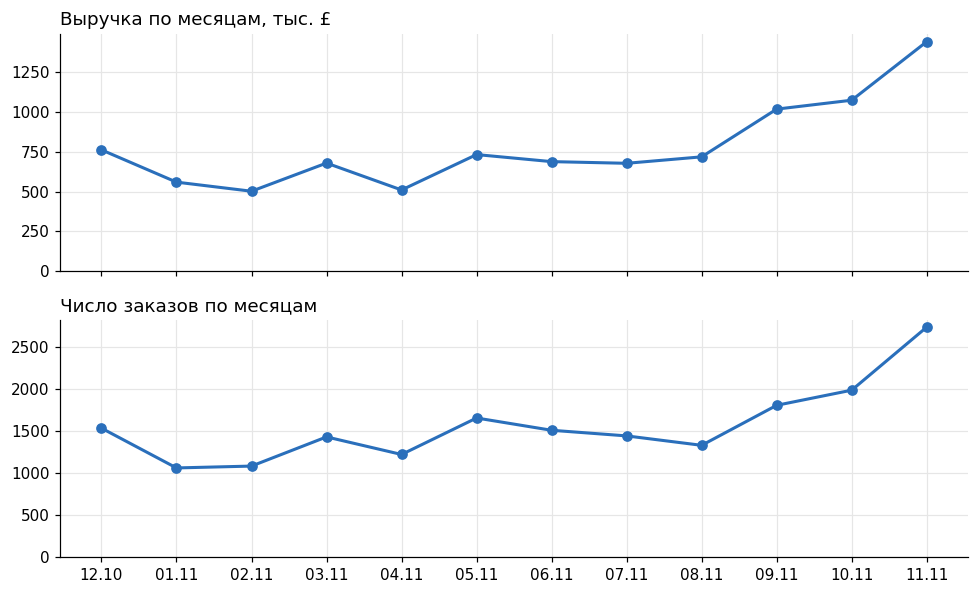

,Revenue,Orders
Month,,
2010-12,"761,398.25",1536
2011-01,"559,228.31",1063
2011-02,"502,278.94",1085
2011-03,"678,628.98",1432
2011-04,"510,152.83",1223
2011-05,"731,869.91",1657
2011-06,"687,757.23",1511
2011-07,"677,266.14",1444
2011-08,"717,715.74",1332


In [25]:
def monthly_totals(sales):
    """Считает выручку и число заказов по месяцам."""
    return sales.groupby("Month").agg(Revenue=("Revenue", "sum"), Orders=("Invoice", "nunique"))


monthly_main = monthly_totals(sales_main)
monthly_prev = monthly_totals(sales_prev)
month_labels = monthly_main.index.strftime("%m.%y")

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(month_labels, monthly_main["Revenue"] / 1000, color=COLOR_MAIN, lw=2, marker="o")
axes[0].set_title("Выручка по месяцам, тыс. £", loc="left")
axes[1].plot(month_labels, monthly_main["Orders"], color=COLOR_MAIN, lw=2, marker="o")
axes[1].set_title("Число заказов по месяцам", loc="left")
for ax in axes:
    ax.set_ylim(0)
plt.tight_layout()
plt.show()

display(monthly_main)

**Вывод.** У продаж выраженная сезонность. С января по август выручка держится в диапазоне от £0,50 до £0,73 млн в месяц, с сентября растёт и в ноябре достигает £1,44 млн. Это в 2,9 раза больше, чем в феврале (£0,50 млн). Число заказов повторяет ту же форму: 2 738 в ноябре против 1 063 в январе.

Причина в профиле магазина. Подарки и декор покупают к Рождеству, причём оптовые клиенты закупаются заранее, в сентябре, октябре и ноябре. Январь и февраль дают спад после праздников.

Для XYZ это важно. Даже у ходового товара осенью продажи в два-три раза выше, чем весной, и коэффициент вариации от этого растёт. Хватает ли одной общей сезонности, чтобы товар попал в класс Z, я проверяю в разделе 4.3.

### 2.3. Концентрация выручки

In [26]:
sku_revenue = sales_main.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)
n_sku = len(sku_revenue)

top10 = sku_revenue.head(10).to_frame()
top10["Description"] = top10.index.map(product_names)
top10["Share, %"] = top10["Revenue"] / total_revenue * 100
display(top10)

print(f"Топ-10 SKU: {top10['Revenue'].sum() / total_revenue:.1%} выручки")
print(f"Верхний 1% SKU ({n_sku // 100} шт.): {sku_revenue.head(n_sku // 100).sum() / total_revenue:.1%} выручки")
print(f"Нижние 50% SKU: {sku_revenue.tail(n_sku // 2).sum() / total_revenue:.1%} выручки")
print(f"SKU с выручкой меньше £100 за год: {(sku_revenue < 100).mean():.1%} ассортимента")

,Revenue,Description,"Share, %"
StockCode,,,
22423,"162,609.57",REGENCY CAKESTAND 3 TIER,1.74
47566,"97,692.00",PARTY BUNTING,1.04
85123A,"95,590.05",WHITE HANGING HEART T-LIGHT HOLDER,1.02
85099B,"90,416.85",JUMBO BAG RED RETROSPOT,0.97
23084,"57,179.17",RABBIT NIGHT LIGHT,0.61
22086,"56,967.18",PAPER CHAIN KIT 50'S CHRISTMAS,0.61
84879,"56,715.87",ASSORTED COLOUR BIRD ORNAMENT,0.61
79321,"51,102.07",CHILLI LIGHTS,0.55
22197,"45,745.42",SMALL POPCORN HOLDER,0.49


Топ-10 SKU: 8.1% выручки
Верхний 1% SKU (37 шт.): 16.9% выручки
Нижние 50% SKU: 4.2% выручки
SKU с выручкой меньше £100 за год: 21.8% ассортимента


**Вывод.** Выручка сильно сконцентрирована. Топ-10 товаров дают 8,1% выручки, верхний 1% ассортимента (37 SKU) даёт 16,9%. Нижняя половина ассортимента, почти 1 900 SKU, приносит 4,2%. У 21,8% товаров выручка за год меньше £100.

При этом лидер, трёхъярусная подставка для тортов, занимает всего 1,7%. От одного-двух хитов магазин не зависит, выручку формирует широкий слой из нескольких сотен товаров.

## 3. ABC-анализ

### 3.1. Расчёт ABC

In [27]:
def classify(values, bounds):
    """Присваивает класс по верхним границам: значение попадает в первый класс, чья граница не меньше него."""
    return pd.cut(values, bins=[-np.inf, *bounds.values()], labels=list(bounds)).astype(str)


def abc_analysis(sales, bounds=ABC_BOUNDS):
    """Считает ABC по выручке.

    Args:
        sales: очищенные продажи.
        bounds: верхние границы накопительной доли выручки для классов.

    Returns:
        Таблицу по StockCode: выручка, доля, накопительная доля и класс ABC,
        отсортированную по убыванию выручки.
    """
    abc = sales.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False).to_frame()
    abc["RevenueShare"] = abc["Revenue"] / abc["Revenue"].sum()
    abc["CumShare"] = abc["RevenueShare"].cumsum()
    abc["ABC"] = classify(abc["CumShare"], bounds)
    return abc


abc = abc_analysis(sales_main)
display(abc.head())

,Revenue,RevenueShare,CumShare,ABC
StockCode,,,,
22423,"162,609.57",0.02,0.02,A
47566,"97,692.00",0.01,0.03,A
85123A,"95,590.05",0.01,0.04,A
85099B,"90,416.85",0.01,0.05,A
23084,"57,179.17",0.01,0.05,A


### 3.2. Сводка по классам

In [28]:
abc_summary = abc.groupby("ABC").agg(SKU=("Revenue", "size"), Revenue=("Revenue", "sum"))
abc_summary["SKU, %"] = abc_summary["SKU"] / abc_summary["SKU"].sum() * 100
abc_summary["Revenue, %"] = abc_summary["Revenue"] / abc_summary["Revenue"].sum() * 100
display(abc_summary)

# По три товара из начала каждого класса
examples = abc.groupby("ABC").head(3).copy()
examples["Description"] = examples.index.map(product_names)
display(examples[["ABC", "Description", "Revenue"]])

,SKU,Revenue,"SKU, %","Revenue, %"
ABC,,,,
A,831,"7,481,637.84",21.96,79.98
B,964,"1,405,022.02",25.47,15.02
C,1990,"468,275.42",52.58,5.01


,ABC,Description,Revenue
StockCode,,,
22423,A,REGENCY CAKESTAND 3 TIER,"162,609.57"
47566,A,PARTY BUNTING,"97,692.00"
85123A,A,WHITE HANGING HEART T-LIGHT HOLDER,"95,590.05"
22582,B,PACK OF 6 SWEETIE GIFT BOXES,"2,593.39"
23100,B,SILVER BELLS TABLE DECORATION,"2,593.33"
22930,B,BAKING MOULD HEART MILK CHOCOLATE,"2,592.35"
21287,C,SCENTED VELVET LOUNGE CANDLE,754.45
22336,C,DOVE DECORATION PAINTED ZINC,754.03
22685,C,FRENCH BLUE METAL DOOR SIGN 0,753.94


**Вывод.** Класс присваивается по накопительной доле выручки. Товары отсортированы по убыванию выручки; пока накопленная доля не превышает 80%, это класс A, до 95% идёт B, остальное C.

| Класс | SKU | Доля ассортимента | Доля выручки |
|---|---|---|---|
| A | 831 | 22,0% | 80,0% |
| B | 964 | 25,5% | 15,0% |
| C | 1 990 | 52,6% | 5,0% |

Распределение близко к классическому правилу Парето. Границы 80 и 95 я оставила стандартными: кривая плавная, изломов, которые подсказали бы другие пороги, на ней нет. Граница между B и C проходит на уровне £755 выручки в год.

### 3.3. Кривая Парето

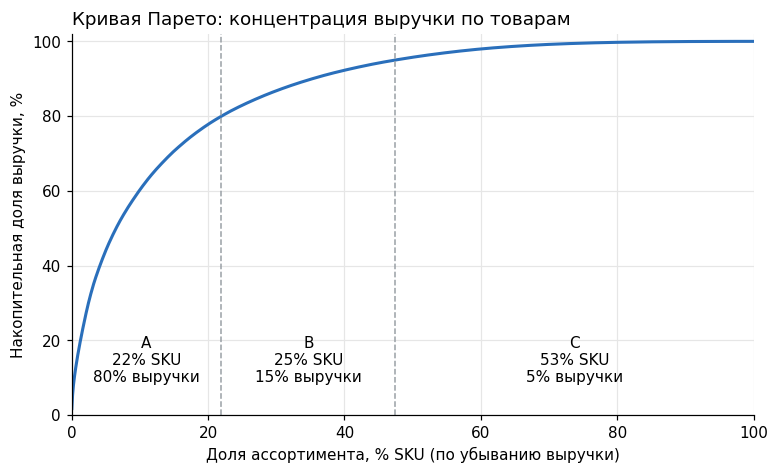

In [29]:
sku_share = np.arange(1, len(abc) + 1) / len(abc) * 100
revenue_share = abc["CumShare"].to_numpy() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sku_share, revenue_share, color=COLOR_MAIN, lw=2)

left = 0
for abc_class in ["A", "B", "C"]:
    right = abc_summary.loc[:abc_class, "SKU, %"].sum()
    if abc_class != "C":
        ax.axvline(right, color=COLOR_MUTED, lw=1, ls="--")
    ax.text((left + right) / 2, 8,
            f"{abc_class}\n{abc_summary.loc[abc_class, 'SKU, %']:.0f}% SKU\n"
            f"{abc_summary.loc[abc_class, 'Revenue, %']:.0f}% выручки",
            ha="center", va="bottom")
    left = right

ax.set_xlabel("Доля ассортимента, % SKU (по убыванию выручки)")
ax.set_ylabel("Накопительная доля выручки, %")
ax.set_title("Кривая Парето: концентрация выручки по товарам", loc="left")
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
plt.show()

**Вывод.** 22% ассортимента дают 80% выручки, а больше половины товаров только 5%. Кривая круто растёт в начале и почти горизонтальна после 50% SKU. Длинный «хвост» в деньгах почти незаметен, но именно эти позиции составляют большую часть того, что нужно хранить и закупать.

### 3.4. Переходы между классами год к году

In [30]:
abc_prev = abc_analysis(sales_prev)

transitions = pd.crosstab(
    abc_prev["ABC"].reindex(abc.index).fillna("не продавался").rename("Класс год назад"),
    abc["ABC"].rename("Класс сейчас"),
    margins=True, margins_name="Всего",
)
display(transitions)

Класс сейчас,A,B,C,Всего
Класс год назад,,,,
A,542,237,70,849
B,60,394,418,872
C,16,108,1288,1412
не продавался,213,225,214,652
Всего,831,964,1990,3785


**Вывод.** Классы подвижны, особенно на границах.

Из 849 прошлогодних A-товаров, которые продаются и сейчас, в классе A остались 542. Ещё 237 перешли в B и 70 в C.

652 товара год назад не продавались совсем, и 213 из них сразу попали в класс A. Обновление ассортимента приносит магазину заметную часть выручки.

В нынешнем классе C 1 288 товаров были там же год назад, это устойчивый «хвост». Ещё 418 опустились из B и 70 из A.

Получается, что ABC за один год показывает состояние на момент расчёта. Товар, только что перешедший из B в C, и товар, второй год лежащий в C, требуют разных решений.

### 3.5. Устойчивость ABC к возвратам

In [31]:
# Другой способ учесть возвраты: ничего не сопоставлять, а вычесть все возвраты периода из всех продаж.
# В строках возвратов количество отрицательное, поэтому их выручка вычитается сама при сложении.
period_rows = filter_period(data, MAIN_START, MAIN_END).drop_duplicates()
net_rows = period_rows[
    period_rows["StockCode"].isin(abc.index)
    & (period_rows["Price"] > 0)
    & ~period_rows["Invoice"].str.startswith("A")
]
abc_net = abc_analysis(net_rows)

display(pd.crosstab(abc["ABC"].rename("Класс в основном расчёте"),
                    abc_net["ABC"].reindex(abc.index).rename("Класс за вычетом всех возвратов")))
changed = (abc["ABC"] != abc_net["ABC"].reindex(abc.index)).sum()
print(f"Сменили класс: {changed} товаров из {len(abc)} ({changed / len(abc):.1%})")
print(f"Выручка за вычетом всех возвратов: {net_rows['Revenue'].sum() / total_revenue:.1%} от выручки основного расчёта")

Класс за вычетом всех возвратов,A,B,C
Класс в основном расчёте,,,
A,827,4,0
B,1,956,7
C,0,4,1986


Сменили класс: 16 товаров из 3785 (0.4%)
Выручка за вычетом всех возвратов: 99.7% от выручки основного расчёта


**Вывод.** В разделе 1.11 я удаляла только покупки, отменённые целиком, а частичные возвраты из выручки не вычитала. Здесь проверен противоположный способ: из всех продаж периода вычтены все возвраты, без сопоставления. Выручка при этом получается на 0,3% меньше.

Класс сменили 16 товаров из 3 785, это 0,4%, и все переходы произошли между соседними классами. Способ обработки возвратов на ABC почти не влияет, поэтому допущение о частичных возвратах результат не искажает.

### 3.6. Вывод по ABC

Класс C означает низкий вклад в выручку за выбранный период и ничего больше. В него попадают товары без спроса, но рядом с ними оказываются новинки, появившиеся за два-три месяца до конца периода, дешёвые товары с большим числом покупателей и сезонные позиции с коротким сезоном.

Поэтому как список на удаление я ABC не использую. Он даёт первый фильтр по экономической значимости. Дальше нужны стабильность спроса, возраст товара и его роль в заказах.

## 4. XYZ-анализ

### 4.1. Ряд «товар × месяц»

In [32]:
def monthly_quantity(sales, start, end):
    """Строит таблицу «товар × месяц» с количеством проданных единиц.

    В таблице есть все месяцы периода: если товар в каком-то месяце
    не продавался, там стоит ноль, а не пропуск.
    """
    months = pd.period_range(start, end, freq="M")
    return (
        sales.pivot_table(index="StockCode", columns="Month", values="Quantity", aggfunc="sum", fill_value=0)
        .reindex(columns=months, fill_value=0)
    )


quantity_main = monthly_quantity(sales_main, MAIN_START, MAIN_END)

assert quantity_main.shape == (sales_main["StockCode"].nunique(), 12)
assert quantity_main.sum().sum() == sales_main["Quantity"].sum()

print("Товаров и месяцев:", quantity_main.shape)
print(f"Доля нулевых ячеек «товар-месяц»: {(quantity_main == 0).mean().mean():.1%}")
display(quantity_main.head())

Товаров и месяцев: (3785, 12)
Доля нулевых ячеек «товар-месяц»: 31.9%


,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11
StockCode,,,,,,,,,,,,
10002,251,340,52,28,189,0,0,0,0,0,0,0
10080,0,0,2,0,0,0,60,24,60,60,6,91
10120,16,0,30,28,0,3,0,5,35,10,10,49
10123C,1,0,0,4,0,0,0,0,0,0,0,0
10124A,4,0,3,5,0,0,0,0,0,0,0,4


В таблице 3 785 товаров и ровно 12 месяцев у каждого. Почти треть ячеек (31,9%) занята нулями: товар в этом месяце не продавался. Нули я сохраняю намеренно. Если считать вариацию только по месяцам с продажами, товар, проданный один раз, получит CV = 0 и попадёт в самые стабильные.

Две проверки в ячейке подтверждают, что столбцов 12 и что сумма по таблице равна общему числу проданных единиц. Ни одна продажа не потерялась.

### 4.2. Расчёт CV и класса

In [33]:
def xyz_analysis(quantity, bounds=XYZ_BOUNDS):
    """Считает коэффициент вариации месячных продаж и класс XYZ.

    Стандартное отклонение берётся по генеральной совокупности (ddof=0):
    12 месяцев: это весь анализируемый период, а не выборка из него.
    """
    xyz = pd.DataFrame({
        "MeanQty": quantity.mean(axis=1),
        "StdQty": quantity.std(axis=1, ddof=0),
    })
    xyz["CV"] = xyz["StdQty"] / xyz["MeanQty"]
    xyz["XYZ"] = classify(xyz["CV"], bounds)
    return xyz


xyz = xyz_analysis(quantity_main)

xyz_summary = xyz["XYZ"].value_counts().sort_index().to_frame("SKU")
xyz_summary["SKU, %"] = xyz_summary["SKU"] / len(xyz) * 100
display(xyz_summary)

,SKU,"SKU, %"
XYZ,,
X,376,9.93
Y,1082,28.59
Z,2327,61.48


### 4.3. Распределение CV

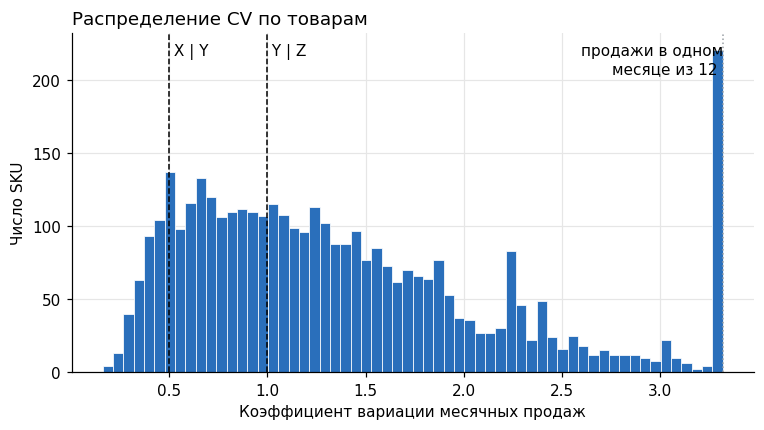

,count,mean,std,min,10%,25%,50%,75%,90%,max
CV,"3,785.00",1.38,0.80,0.16,0.50,0.76,1.22,1.82,2.55,3.32


In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xyz["CV"], bins=60, color=COLOR_MAIN, edgecolor="white", linewidth=0.5)
for bound, label in [(0.5, "X | Y"), (1.0, "Y | Z")]:
    ax.axvline(bound, color="black", lw=1, ls="--")
    ax.text(bound, ax.get_ylim()[1] * 0.97, f" {label}", va="top")
ax.axvline(np.sqrt(11), color=COLOR_MUTED, lw=1, ls=":")
ax.text(np.sqrt(11), ax.get_ylim()[1] * 0.97, "продажи в одном\nмесяце из 12 ", va="top", ha="right")
ax.set_xlabel("Коэффициент вариации месячных продаж")
ax.set_ylabel("Число SKU")
ax.set_title("Распределение CV по товарам", loc="left")
plt.show()

display(xyz["CV"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T)

**Вывод.** Со стандартными порогами 0,5 и 1 распределение получается сильно скошенным.

| Класс | SKU | Доля |
|---|---|---|
| X (CV ≤ 0,5) | 376 | 9,9% |
| Y (0,5 < CV ≤ 1) | 1 082 | 28,6% |
| Z (CV > 1) | 2 327 | 61,5% |

Медианный CV равен 1,22, то есть типичный товар магазина формально «непредсказуем». Правый край гистограммы обрывается на 3,32. Это √11, такое значение CV получает товар, проданный только в одном месяце из двенадцати.

Пороги я оставила стандартными. Если сдвинуть их вправо, классы просто переименуются, а главный факт спрячется: спрос в этом магазине нестабилен почти у всего ассортимента. Вместо этого ниже я разбираю, из чего состоит класс Z.

In [35]:
# Может ли общая сезонность магазина сама по себе дать класс Z?
shop_quantity = quantity_main.sum()
print(f"CV продаж магазина в целом: {shop_quantity.std(ddof=0) / shop_quantity.mean():.2f}")

# Убираем общую сезонность: продажи каждого месяца делим на сезонный индекс магазина
seasonal_index = shop_quantity / shop_quantity.mean()
xyz_deseasonalized = xyz_analysis(quantity_main / seasonal_index)
display(pd.crosstab(
    xyz["XYZ"].rename("Класс по исходным данным"),
    xyz_deseasonalized["XYZ"].rename("Класс без общей сезонности"),
    margins=True, margins_name="Всего",
))

CV продаж магазина в целом: 0.32


Класс без общей сезонности,X,Y,Z,Всего
Класс по исходным данным,,,,
X,258,118,0,376
Y,81,889,112,1082
Z,0,107,2220,2327
Всего,339,1114,2332,3785


**Проверка: общая сезонность и класс Z.** В разделе 2.2 было видно, что осенью магазин продаёт в два-три раза больше, чем весной. Я проверила, может ли это само по себе объяснить высокий CV.

CV продаж магазина в целом равен 0,32. Товар, который в точности повторяет общий профиль магазина, попал бы в класс X.

Вторая проверка: я поделила продажи каждого месяца на сезонный индекс магазина (отношение продаж месяца к среднемесячным) и пересчитала классы. Распределение почти не изменилось: в X 339 товаров вместо 376, в Z 2 332 вместо 2 327. Ни один товар не перешёл из Z в X.

Общая сезонность магазина класс Z не объясняет. Высокий CV у большинства товаров вызван другим. Продажи идут с перерывами: почти треть ячеек «товар-месяц» пустые. Часть товаров появилась или исчезла внутри периода. У части есть собственный сезон, который не совпадает с общим. Эти причины разобраны ниже.

### 4.4. Возраст товара

In [36]:
sales_both = pd.concat([sales_prev, sales_main])
first_sale = sales_both.groupby("StockCode")["Month"].min().reindex(xyz.index)

xyz["FirstSale"] = first_sale
xyz["IsNew"] = first_sale >= NEW_FROM

print("Товаров, впервые проданных в основном периоде:", (first_sale >= MAIN_START).sum())
print(f"Из них новых (первая продажа с {NEW_FROM}):", xyz["IsNew"].sum())
display(pd.crosstab(xyz["XYZ"], xyz["IsNew"].map({True: "новый", False: "не новый"})))

Товаров, впервые проданных в основном периоде: 652
Из них новых (первая продажа с 2011-06): 432


IsNew,не новый,новый
XYZ,,
X,376,0
Y,1082,0
Z,1895,432


In [37]:
# CV новых товаров, посчитанный с месяца первой продажи.
# Накопленная сумма равна нулю, пока товар не появился: эти месяцы заменяются пропусками и в расчёт не входят.
new_quantity = quantity_main[xyz["IsNew"]]
since_first_sale = new_quantity.where(new_quantity.cumsum(axis=1) > 0)
has_history = since_first_sale.notna().sum(axis=1) >= 3

xyz_new = xyz_analysis(since_first_sale[has_history])
print("Новых товаров с историей от трёх месяцев:", has_history.sum())
display(xyz_new["XYZ"].value_counts().sort_index().to_frame("SKU"))

Новых товаров с историей от трёх месяцев: 288


,SKU
XYZ,
X,139
Y,138
Z,11


**Вывод.** 652 товара впервые проданы внутри основного периода. Из них 432 появились в июне 2011 или позже. У них меньше полугода истории, и я отмечаю их как новые.

Все 432 новых товара попали в класс Z. Так устроен расчёт: в начале их ряда стоят нули за месяцы, когда товара ещё не существовало, и CV получается высоким автоматически. Это подтверждает вторая ячейка: если считать CV с месяца первой продажи, из 288 новинок с историей от трёх месяцев 139 попадают в X, 138 в Y и только 11 в Z. Но ряд из трёх-шести месяцев слишком короткий для надёжного класса, поэтому новинки я оставляю отдельной группой и в кандидаты на вывод не включаю.

Есть ограничение. Данные начинаются в декабре 2009, поэтому товары, существовавшие раньше, выглядят появившимися именно тогда. На определение новинок 2011 года это не влияет.

### 4.5. Сезонность в классе Z

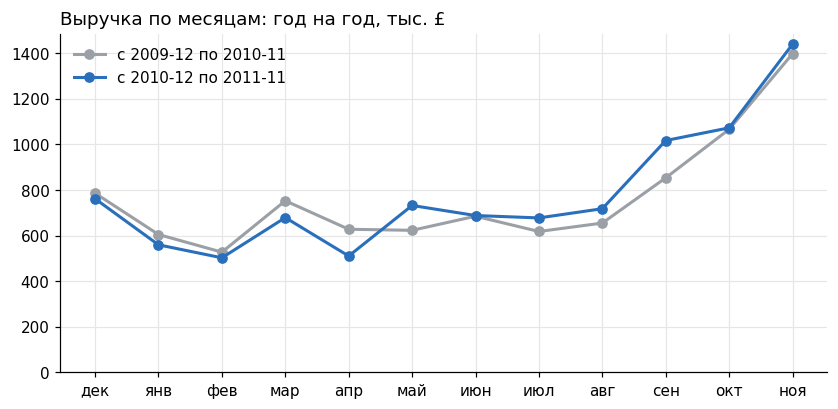

In [38]:
calendar_labels = ["дек", "янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(calendar_labels, monthly_prev["Revenue"].to_numpy() / 1000, color=COLOR_MUTED, lw=2, marker="o",
        label=f"с {PREV_START} по {PREV_END}")
ax.plot(calendar_labels, monthly_main["Revenue"].to_numpy() / 1000, color=COLOR_MAIN, lw=2, marker="o",
        label=f"с {MAIN_START} по {MAIN_END}")
ax.set_ylim(0)
ax.set_title("Выручка по месяцам: год на год, тыс. £", loc="left")
ax.legend(frameon=False)
plt.show()

In [39]:
# Сезонный товар повторяет прошлогодний рисунок продаж по месяцам.
# Мера повторяемости: корреляция двух рядов из 12 месяцев: этого года и прошлого.
quantity_prev = monthly_quantity(sales_prev, PREV_START, PREV_END)
in_both_years = quantity_main.index.intersection(quantity_prev.index)

this_year = quantity_main.loc[in_both_years].to_numpy().T
last_year = quantity_prev.loc[in_both_years].to_numpy().T
yoy_corr = pd.DataFrame(this_year, columns=in_both_years).corrwith(pd.DataFrame(last_year, columns=in_both_years))

xyz["YoYCorr"] = yoy_corr.reindex(xyz.index)
# Корреляция надёжна, только если товар продаётся регулярно:
# при трёх-пяти заказах за год её задают один-два совпавших месяца
orders_main = sales_main.groupby("StockCode")["Invoice"].nunique().reindex(xyz.index)
orders_prev = sales_prev.groupby("StockCode")["Invoice"].nunique().reindex(xyz.index).fillna(0)
xyz["EnoughOrders"] = (orders_main >= MIN_SEASONAL_ORDERS) & (orders_prev >= MIN_SEASONAL_ORDERS)
xyz["Seasonal"] = (xyz["YoYCorr"] >= SEASONAL_CORR) & xyz["EnoughOrders"]
xyz["LastSale"] = sales_main.groupby("StockCode")["Month"].max()
xyz["Stopped"] = xyz["LastSale"] <= STOPPED_BY

print("Товаров, продававшихся в оба года:", len(in_both_years))
print("Из них с корреляцией не ниже порога:", (xyz["YoYCorr"] >= SEASONAL_CORR).sum())
print("Из них с достаточным числом заказов (сезонные):", xyz["Seasonal"].sum())

Товаров, продававшихся в оба года: 3133
Из них с корреляцией не ниже порога: 482
Из них с достаточным числом заказов (сезонные): 433


In [40]:
# Почему товар попал в Z: новый, продажи прекратились, сезонный или причина не найдена
z_products = xyz[xyz["XYZ"] == "Z"]
z_reason = pd.Series(
    np.select(
        [z_products["IsNew"], z_products["Stopped"], z_products["Seasonal"]],
        ["Новый товар", "Продажи прекратились", "Сезонный спрос"],
        default="Объяснение не найдено",
    ),
    index=z_products.index,
)
z_summary = pd.DataFrame({
    "SKU": z_reason.value_counts(),
    "Revenue, %": abc["Revenue"].groupby(z_reason).sum() / total_revenue * 100,
})
z_summary["SKU, % от Z"] = z_summary["SKU"] / len(z_products) * 100
display(z_summary.sort_values("SKU", ascending=False))

# Самые крупные сезонные товары класса Z
seasonal_z = z_products[z_reason == "Сезонный спрос"].join(abc["Revenue"]).sort_values("Revenue", ascending=False)
seasonal_z.insert(0, "Description", seasonal_z.index.map(product_names))
display(seasonal_z[["Description", "Revenue", "CV", "YoYCorr"]].head(8))

,SKU,"Revenue, %","SKU, % от Z"
Объяснение не найдено,1249,12.89,53.67
Новый товар,432,9.48,18.56
Продажи прекратились,398,0.98,17.10
Сезонный спрос,248,8.04,10.66


,Description,Revenue,CV,YoYCorr
StockCode,,,,
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"56,967.18",1.59,0.98
22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,"29,300.13",1.42,0.91
22112,CHOCOLATE HOT WATER BOTTLE,"29,254.34",1.10,0.98
22114,HOT WATER BOTTLE TEA AND SYMPATHY,"29,100.04",1.45,0.88
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"23,714.60",1.48,0.83
22111,SCOTTIE DOG HOT WATER BOTTLE,"22,198.63",1.12,0.79
84029E,RED WOOLLY HOTTIE WHITE HEART.,"20,169.88",1.61,0.80
21479,WHITE SKULL HOT WATER BOTTLE,"18,519.54",1.41,0.88


**Вывод.** На графике два года почти совпадают по форме: спад в январе и феврале, рост с сентября, пик в ноябре. Сезонность магазина устойчива.

Для каждого товара, продававшегося в оба года, я посчитала корреляцию двух помесячных рядов. Если она не ниже 0,6, товар повторяет прошлогодний рисунок. Таких товаров 482. Но у 49 из них меньше шести заказов хотя бы в одном из двух лет. При таком числе заказов корреляцию задают один-два совпавших месяца, и доверять ей нельзя. Сезонными я считаю оставшиеся 433 товара.

Класс Z (2 327 товаров) раскладывается по причинам так:

| Причина высокой вариативности | SKU | Доля Z | Доля выручки магазина |
|---|---|---|---|
| Объяснение не найдено | 1 249 | 53,7% | 12,9% |
| Новый товар | 432 | 18,6% | 9,5% |
| Продажи прекратились до июня 2011 | 398 | 17,1% | 1,0% |
| Сезонный спрос | 248 | 10,7% | 8,0% |

У 46% класса Z нашлось понятное объяснение. Крупнейшие сезонные товары здесь рождественские гирлянды и грелки. CV у них от 1,1 до 1,6, но корреляция с прошлым годом от 0,8 до 0,98. Их спрос сильно колеблется, но хорошо прогнозируется.

### 4.6. Вывод по XYZ

Читать Z как «непредсказуемый спрос» в этих данных некорректно. Высокий CV возникает по четырём причинам, и только одна из них связана с хаотичностью.

При сезонности колебания большие, но повторяются, и закупку можно планировать по прошлому году. У новинки ряд короткий, оценивать стабильность рано. Если продажи прекратились, товар закончился или уже выведен. И только редкие и оптовые заказы дают спрос, который трудно прогнозировать.

Кроме того, продажи не равны спросу. Нулевой месяц может означать, что товара не было на складе, и без данных об остатках такие случаи не отличить.

## 5. Матрица ABC/XYZ

### 5.1. Объединение

In [41]:
features = sales_main.groupby("StockCode").agg(
    Quantity=("Quantity", "sum"),
    Orders=("Invoice", "nunique"),
    Customers=("Customer ID", "nunique"),
    ActiveMonths=("Month", "nunique"),
)

sku = abc.join(xyz).join(features)
sku.insert(0, "Description", sku.index.map(product_names))
sku["AvgPrice"] = sku["Revenue"] / sku["Quantity"]
sku["Group"] = sku["ABC"] + sku["XYZ"]

assert len(sku) == n_sku and sku["Group"].notna().all()
display(sku[["Description", "Revenue", "RevenueShare", "ABC", "CV", "XYZ", "Group"]].head())

,Description,Revenue,RevenueShare,ABC,CV,XYZ,Group
StockCode,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"162,609.57",0.02,A,0.30,X,AX
47566,PARTY BUNTING,"97,692.00",0.01,A,0.63,Y,AY
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"95,590.05",0.01,A,0.36,X,AX
85099B,JUMBO BAG RED RETROSPOT,"90,416.85",0.01,A,0.32,X,AX
23084,RABBIT NIGHT LIGHT,"57,179.17",0.01,A,1.91,Z,AZ


### 5.2. Метрики по группам

In [42]:
sales_grouped = sales_main.merge(sku[["Group"]], left_on="StockCode", right_index=True)

matrix = sales_grouped.groupby("Group").agg(
    Revenue=("Revenue", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Invoice", "nunique"),
    Customers=("Customer ID", "nunique"),
)
matrix.insert(0, "SKU", sku.groupby("Group").size())
matrix.insert(1, "SKU, %", matrix["SKU"] / n_sku * 100)
matrix.insert(3, "Revenue, %", matrix["Revenue"] / total_revenue * 100)
matrix["ActiveMonths (медиана)"] = sku.groupby("Group")["ActiveMonths"].median()
matrix["AvgPrice (медиана)"] = sku.groupby("Group")["AvgPrice"].median()
display(matrix)

,SKU,"SKU, %",Revenue,"Revenue, %",Quantity,Orders,Customers,ActiveMonths (медиана),AvgPrice (медиана)
Group,,,,,,,,,
AX,234,6.18,"2,569,100.06",27.46,1391053,15376,3972,12.00,1.88
AY,320,8.45,"2,968,865.93",31.74,1308397,16179,4041,12.00,2.53
AZ,277,7.32,"1,943,671.85",20.78,751977,13172,3689,7.00,3.02
BX,118,3.12,"190,313.65",2.03,194818,7473,2592,12.00,1.37
BY,365,9.64,"533,272.12",5.70,458286,11159,3457,12.00,1.65
BZ,481,12.71,"681,436.25",7.28,510980,10830,3430,8.00,1.71
CX,24,0.63,"11,696.29",0.13,17094,1436,699,12.00,0.87
CY,397,10.49,"145,894.97",1.56,150317,6186,2357,11.00,1.42
CZ,1569,41.45,"310,684.16",3.32,311624,8021,2846,5.00,2.03


**Вывод.** Группы резко различаются по весу.

AX и AY вместе дают 554 товара, 14,6% ассортимента и 59,2% выручки. Товары группы AX встречаются в 82% заказов. Это ядро ассортимента.

В AZ 277 товаров и 20,8% выручки. Медиана активных месяцев 7 из 12: здесь сосредоточены новинки (104 товара) и сезонные позиции (63).

BX, BY и BZ содержат 964 товара и 15% выручки. В CX всего 24 товара, дешёвых и со стабильным спросом, их купили 699 покупателей.

CZ оказалась самой большой группой: 1 569 товаров, 41,5% ассортимента, 3,3% выручки. Медианный товар продавался 5 месяцев из 12. При этом товары CZ есть в 8 021 заказе, то есть в 43% всех заказов, и их покупали 2 846 клиентов из 4 281. Вклад в выручку мал, но в корзинах эти товары встречаются часто.

### 5.3. Тепловая карта

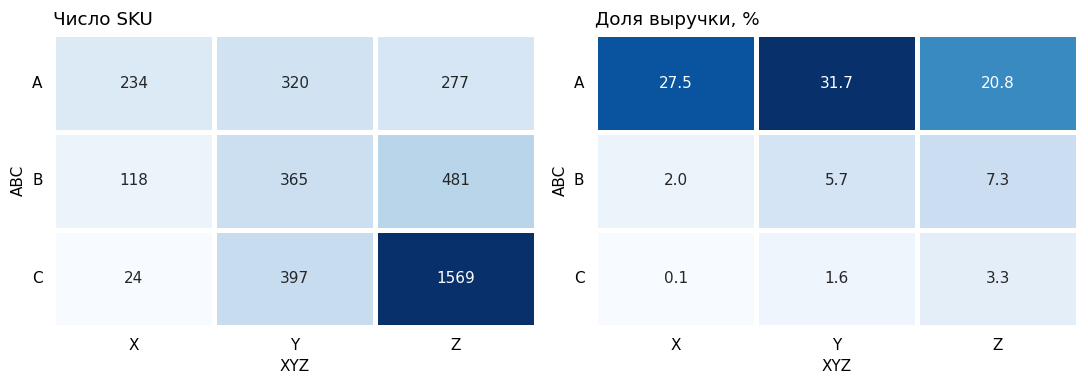

In [43]:
sku_matrix = sku.pivot_table(index="ABC", columns="XYZ", values="Revenue", aggfunc="size")
revenue_matrix = sku.pivot_table(index="ABC", columns="XYZ", values="RevenueShare", aggfunc="sum") * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
heatmap_style = dict(cmap="Blues", cbar=False, linewidths=2, linecolor="white", annot=True)
sns.heatmap(sku_matrix, fmt="d", ax=axes[0], **heatmap_style)
axes[0].set_title("Число SKU", loc="left")
sns.heatmap(revenue_matrix, fmt=".1f", ax=axes[1], **heatmap_style)
axes[1].set_title("Доля выручки, %", loc="left")
for ax in axes:
    ax.grid(False)
    ax.tick_params(left=False, bottom=False)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Вывод.** Две карты показывают одну матрицу с двух сторон. По числу товаров самая тяжёлая клетка CZ, в правом нижнем углу. По выручке лидируют AX и AY в левом верхнем. Ассортимент и деньги сосредоточены в противоположных углах: большая часть позиций, которыми нужно управлять, почти не приносит выручки.

## 6. Стратегия управления группами

| Группа | Что видно в данных | Как управлять |
|---|---|---|
| **AX** | 234 SKU, 27,5% выручки, продаются все 12 месяцев, есть в 82% заказов | Постоянное наличие, страховой запас, контроль дефицита в первую очередь. Отсутствие такого товара бьёт по большинству заказов |
| **AY** | 320 SKU, 31,7% выручки, крупнейшая группа по деньгам | Постоянное наличие, но запас планировать по месяцам: к осени увеличивать в два-три раза по образцу прошлого года |
| **AZ** | 277 SKU, 20,8% выручки; 104 новинки и 63 сезонных товара | Единой стратегии нет. Сезонные закупать под сезон по прошлогоднему профилю. Новинки наблюдать и переоценить через полгода. Для остальных небольшой запас и закупка под крупные заказы |
| **BX** | 118 SKU, 2,0% выручки, стабильный спрос | Стандартное автоматическое пополнение, минимум внимания |
| **BY** | 365 SKU, 5,7% выручки | Стандартное пополнение с сезонной поправкой |
| **BZ** | 481 SKU, 7,3% выручки, медиана 8 активных месяцев | Ограниченный запас. Сезонные и новые вести как в AZ, остальные проверять раз в полгода: растут или уходят в C |
| **CX** | 24 SKU, 0,1% выручки, 699 покупателей | Оставить. Стабильные дешёвые товары, которые регулярно добавляют в заказ; хранить их дёшево, прогнозировать легко |
| **CY** | 397 SKU, 1,6% выручки, медиана 11 активных месяцев | Оставить с минимальным запасом. Спрос небольшой, но регулярный |
| **CZ** | 1 569 SKU, 41,5% ассортимента, 3,3% выручки | Пул для проверки на вывод. Удалять списком нельзя: 179 товаров новые, 106 сезонные. Отбор в разделе 7 |

### 6.1. Группа CZ отдельно

CZ выглядит очевидным кандидатом: 41,5% позиций и 3,3% выручки. Удалить её целиком всё равно нельзя, и причин три.

Во-первых, часть товаров попала туда по техническим причинам. 179 новинок не успели набрать историю, 106 сезонных позиций продаются коротко, но предсказуемо.

Во-вторых, товар может быть дополнением. Съёмная ручка для сковороды сама почти не приносит выручки, но без неё не купят набор сковород. В подарочном магазине такую роль играют открытки, упаковка, мелкие аксессуары к наборам. Дешёвое дополнение будет в классе C всегда, а его исчезновение ударит по продажам товара класса A.

В-третьих, покупатель приходит за корзиной. Товары CZ есть в 43% заказов. Оптовый клиент, который не нашёл привычную мелочь, может уйти к другому поставщику со всем заказом.

Поэтому из CZ я отбираю только те товары, у которых слабость подтверждена несколькими признаками сразу. Товары с устойчивым «партнёром» из класса A отправляю на ручную проверку.

### 6.2. Товары, которые держатся на одном клиенте

In [44]:
# Доля выручки товара, которую даёт его крупнейший покупатель.
# Считается по заказам с известным клиентом: строки без идентификатора в группировку не попадают.
customer_revenue = sales_main.groupby(["StockCode", "Customer ID"])["Revenue"].sum()
sku["TopCustomer"] = customer_revenue.groupby("StockCode").idxmax().map(lambda pair: int(pair[1])).astype("Int64")
sku["TopCustomerShare"] = (customer_revenue.groupby("StockCode").max() / sku["Revenue"]).fillna(0)
sku["OneCustomer"] = sku["TopCustomerShare"] >= ONE_CUSTOMER_SHARE

dependence = sku.groupby("ABC").agg(SKU=("Revenue", "size"), OneCustomer=("OneCustomer", "sum"))
dependence["Revenue, %"] = sku[sku["OneCustomer"]].groupby("ABC")["RevenueShare"].sum() * 100
display(dependence)

dependent_a = sku[sku["OneCustomer"] & (sku["ABC"] == "A")]
print("Группы зависимых товаров класса A:", dependent_a["Group"].value_counts().to_dict())
print("Сколько клиентов за ними стоит:", dependent_a["TopCustomer"].nunique())
display(dependent_a["TopCustomer"].value_counts().head(3).to_frame("Зависимых товаров класса A"))
display(dependent_a.sort_values("Revenue", ascending=False)
        [["Description", "Group", "Revenue", "Orders", "TopCustomer", "TopCustomerShare"]].head(8))

,SKU,OneCustomer,"Revenue, %"
ABC,,,
A,831,32,2.09
B,964,30,0.53
C,1990,317,0.25


Группы зависимых товаров класса A: {'AZ': 30, 'AY': 2}
Сколько клиентов за ними стоит: 9


,Зависимых товаров класса A
TopCustomer,
18102,17
17450,7
15749,2


,Description,Group,Revenue,Orders,TopCustomer,TopCustomerShare
StockCode,,,,,,
21623,VINTAGE UNION JACK MEMOBOARD,AZ,"22,362.04",209,18102,0.74
22189,CREAM HEART CARD HOLDER,AY,"21,963.64",501,18102,0.59
22188,BLACK HEART CARD HOLDER,AZ,"11,601.91",176,18102,0.75
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,AZ,"11,282.24",243,15749,0.58
48173C,DOORMAT BLACK FLOCK,AZ,"10,188.32",191,18102,0.55
23134,LARGE ZINC HEART WALL ORGANISER,AZ,"6,431.11",38,18102,0.89
47556B,TEA TIME TEA TOWELS,AZ,"6,045.00",2,15749,1.00
22783,SET 3 WICKER OVAL BASKETS W LIDS,AZ,"5,961.25",33,18102,0.80


**Вывод.** Для каждого товара я посчитала, какую долю его выручки даёт крупнейший покупатель. Если половину и больше, товар зависит от одного клиента.

В классе A таких товаров 32 из 831, на них приходится 2,1% выручки магазина. За ними стоят всего 9 клиентов, и на одного из них приходится 17 товаров. 30 из 32 товаров относятся к группе AZ. Их высокий CV объясняется тем, что товар берёт один оптовик крупными партиями.

Самый заметный пример: доска для записей с британским флагом, £22 тыс. выручки за год. У товара 209 заказов, но 74% выручки дал один клиент. Тот же клиент стоит за 17 из 32 зависимых товаров.

Для управления запасами это отдельный случай. Держать такой товар на складе в расчёте на общий спрос рискованно: если клиент уйдёт, запас останется. Его разумнее закупать под заказы этого клиента.

В классе C зависимых товаров 317, но там это ожидаемо: у товара с пятью заказами крупнейший покупатель почти всегда даёт большую долю. Расчёт учитывает только заказы с известным клиентом, поэтому для товаров, которые часто покупают без идентификатора, доля может быть занижена.

## 7. Кандидаты на сокращение

### 7.1. Критерии отбора

Кандидатом на вывод я считаю товар, у которого низкая значимость подтверждена несколькими независимыми признаками. Сначала убираю из рассмотрения товары, о которых судить рано, потом выделяю две группы кандидатов.

Заранее исключаю новые и сезонные товары. Новым считается товар с первой продажей в июне 2011 или позже: истории меньше полугода, и высокий CV объясняется нулями до его появления. Сезонным считается товар, у которого корреляция помесячных продаж с прошлым годом не ниже 0,6 и в каждом из двух лет не меньше шести заказов. Его колебания предсказуемы, а нулевые месяцы приходятся на межсезонье.

Первая группа кандидатов: товары класса C, у которых последняя продажа была не позже мая 2011. Они не продавались полгода и дольше, включая пиковый сезон.

Вторая группа: товары CZ, которые ещё продаются, но получили не больше 12 заказов за год (в среднем один в месяц или реже) и не больше 10 покупателей.

Товар из второй группы уходит на ручную проверку, если не меньше половины его заказов содержат один и тот же товар класса A, таких совместных заказов хотя бы пять, и сделали их не меньше трёх разных покупателей. Возможно, это дополнение.

Пороги 12 заказов и 10 покупателей выбраны по распределению класса C. Медиана там 19 заказов и 9 покупателей, то есть отбирается нижняя часть класса. Насколько результат зависит от этих порогов, проверено в разделе 7.5.

У порога по покупателям есть слабое место. 15% выручки приходится на заказы без идентификатора клиента, и у товара, который покупали только так, покупателей в данных ноль. Поэтому условие по покупателям работает только вместе с условием по заказам.

### 7.2. Признаки товара

In [45]:
flags = ["IsNew", "Stopped", "Seasonal"]
flag_counts = sku.groupby("Group")[flags].sum()
flag_counts.loc["Всего"] = flag_counts.sum()
display(flag_counts)

display(sku.loc[sku["ABC"] == "C", ["Revenue", "Orders", "Customers", "ActiveMonths"]]
        .describe(percentiles=[0.25, 0.5, 0.75]))

,IsNew,Stopped,Seasonal
Group,,,
AX,0,0,33
AY,0,0,44
AZ,104,5,63
BX,0,0,10
BY,0,0,51
BZ,149,27,96
CX,0,0,0
CY,0,0,30
CZ,179,366,106


,Revenue,Orders,Customers,ActiveMonths
count,"1,990.00","1,990.00","1,990.00","1,990.00"
mean,235.31,30.38,15.71,6.57
std,226.25,33.08,17.51,3.82
min,0.42,1.00,0.00,1.00
25%,39.98,6.00,3.00,3.00
50%,150.12,19.00,9.00,6.00
75%,405.27,42.00,23.00,10.00
max,754.45,212.00,115.00,12.00


**Вывод.** Признаки распределены по группам ожидаемо.

Прекратившиеся продажи почти целиком сидят в классе C: 366 из 398. Ещё 32 товара классов A и B тоже не продаются с июня. Два из них сезонные, а остальные 30 получают отдельную рекомендацию «проверить наличие». Для значимого товара пропавшие продажи скорее говорят о том, что он закончился на складе.

Сезонные товары есть во всех классах: 140 в A, 157 в B, 136 в C.

Типичный товар класса C за год дал £150 выручки, 19 заказов и 9 покупателей и продавался 6 месяцев из 12. У четверти класса не больше 6 заказов и 3 покупателей.

### 7.3. Роль в корзине

In [46]:
# Состав заказов: каждому товару в заказе соответствует одна строка
baskets = (
    sales_main[["Invoice", "StockCode", "Customer ID"]]
    .drop_duplicates(["Invoice", "StockCode"])
    .merge(sku[["ABC"]], left_on="StockCode", right_index=True)
)
baskets_c = baskets[baskets["ABC"] == "C"]
baskets_a = baskets.loc[baskets["ABC"] == "A", ["Invoice", "StockCode"]]

orders_with_a = set(baskets_a["Invoice"])
print(f"Доля покупок C-товаров в заказах, где есть хотя бы один A-товар: "
      f"{baskets_c['Invoice'].isin(orders_with_a).mean():.1%}")

# Пары «C-товар + A-товар» в одном заказе: сколько таких заказов и сколько разных покупателей их сделали
pairs = baskets_c.merge(baskets_a, on="Invoice", suffixes=("_C", "_A"))
together = (
    pairs.groupby(["StockCode_C", "StockCode_A"])
    .agg(Together=("Invoice", "size"), PairCustomers=("Customer ID", "nunique"))
    .reset_index()
)
together["Confidence"] = together["Together"] / together["StockCode_C"].map(sku["Orders"])

# Частая пара: достаточно совместных заказов, и это не меньше половины заказов C-товара.
# Устойчивая пара: её к тому же покупают разные клиенты, а не один.
frequent = together[(together["Together"] >= MIN_TOGETHER) & (together["Confidence"] >= MIN_CONFIDENCE)]
stable = frequent[frequent["PairCustomers"] >= MIN_PAIR_CUSTOMERS]
print("C-товаров с частым A-партнёром:", frequent["StockCode_C"].nunique())
print(f"Из них пару покупали не меньше {MIN_PAIR_CUSTOMERS} разных клиентов:", stable["StockCode_C"].nunique())

# Для каждого C-товара: A-товар, с которым его покупают чаще всего
companions = (
    stable.sort_values(["Confidence", "Together"], ascending=False)
    .drop_duplicates("StockCode_C")
    .set_index("StockCode_C")
)
sku["Companion"] = sku.index.isin(companions.index)
sku["PartnerA"] = companions["StockCode_A"].reindex(sku.index)

companions_view = companions.assign(
    ProductC=companions.index.map(product_names),
    ProductA=companions["StockCode_A"].map(product_names),
)
display(companions_view.sort_values("Together", ascending=False)
        [["ProductC", "ProductA", "Together", "PairCustomers", "Confidence"]].head(10))

Доля покупок C-товаров в заказах, где есть хотя бы один A-товар: 98.9%


C-товаров с частым A-партнёром: 584
Из них пару покупали не меньше 3 разных клиентов: 237


,ProductC,ProductA,Together,PairCustomers,Confidence
StockCode_C,,,,,
20733,GOLD MINI TAPE MEASURE,SUKI SHOULDER BAG,113,3,0.58
22422,TOOTHPASTE TUBE PEN,JUMBO BAG RED RETROSPOT,107,7,0.60
22135,MINI LADLE LOVE HEART PINK,JUMBO BAG RED RETROSPOT,97,5,0.57
21356,TOAST ITS - FAIRY FLOWER,JAM MAKING SET PRINTED,88,5,0.62
22134,LADLE LOVE HEART RED,SUKI SHOULDER BAG,88,5,0.58
20707,CRAZY DAISY HEART DECORATION,PARTY BUNTING,87,7,0.59
23006,TRAVEL CARD WALLET FLOWER MEADOW,TRAVEL CARD WALLET KEEP CALM,87,48,0.52
85017B,ENVELOPE 50 BLOSSOM IMAGES,VINTAGE PAISLEY STATIONERY SET,81,12,0.52
21015,DARK BIRD HOUSE TREE DECORATION,WOODEN STAR CHRISTMAS SCANDINAVIAN,78,25,0.62


**Вывод.** Простая проверка «покупают ли товар C вместе с товарами A» ничего не различает: 98,9% покупок C-товаров приходятся на заказы, где есть хотя бы один A-товар. Заказы в этом магазине большие, и популярные товары есть почти в каждом.

Поэтому для каждого C-товара я ищу конкретный A-товар, с которым его покупают чаще всего, и считаю долю заказов C-товара, содержащих этого партнёра. Частый партнёр (хотя бы 5 совместных заказов и хотя бы половина всех заказов товара) есть у 584 товаров класса C.

Одной частоты мало. У 347 из этих 584 товаров все совместные заказы сделали один-два покупателя или покупатель неизвестен. Это привычная корзина одного оптового клиента, о связи между товарами она ничего не говорит. Поэтому я добавила третье условие: пару должны покупать не меньше трёх разных клиентов. Его проходят 237 товаров.

К этому результату я всё равно отношусь осторожно. Совместная покупка не доказывает, что один товар нужен для другого. Запретом на вывод этот признак не служит, он даёт повод для ручной проверки.

### 7.4. Итоговый список

In [47]:
REC_NEW = "Наблюдать: новый товар"
REC_SEASONAL = "Оставить: сезонный спрос"
REC_STOPPED = "Вывести: продаж нет 6+ месяцев"
REC_WEAK = "Кандидат на вывод: редкий хаотичный спрос"
REC_COMPANION = "Ручная проверка: покупают вместе с A-товаром"
REC_CHECK_STOCK = "Проверить наличие: продажи значимого товара прекратились"
REC_KEEP = "Оставить"
CANDIDATE_LABELS = [REC_STOPPED, REC_WEAK]


def recommend(sku, max_orders=MAX_ORDERS, max_customers=MAX_CUSTOMERS):
    """Присваивает каждому товару рекомендацию.

    Условия проверяются сверху вниз, срабатывает первое подходящее,
    поэтому новые и сезонные товары в кандидаты не попадают.

    Args:
        sku: таблица товаров с классами и признаками.
        max_orders: порог числа заказов для «редкого спроса».
        max_customers: порог числа покупателей для «редкого спроса».

    Returns:
        Series с текстом рекомендации по каждому StockCode.
    """
    is_c = sku["ABC"] == "C"
    weak = (sku["Group"] == "CZ") & (sku["Orders"] <= max_orders) & (sku["Customers"] <= max_customers)
    conditions = [
        (sku["IsNew"], REC_NEW),
        (sku["Seasonal"], REC_SEASONAL),
        (is_c & sku["Stopped"], REC_STOPPED),
        (~is_c & sku["Stopped"], REC_CHECK_STOCK),
        (weak & sku["Companion"], REC_COMPANION),
        (weak, REC_WEAK),
    ]
    masks, labels = zip(*conditions)
    return pd.Series(np.select(masks, labels, default=REC_KEEP), index=sku.index)


sku["Recommendation"] = recommend(sku)

candidate_columns = ["Description", "ABC", "XYZ", "Group", "Revenue", "RevenueShare", "Quantity",
                     "Orders", "Customers", "ActiveMonths", "LastSale", "Recommendation"]
candidates = sku.loc[sku["Recommendation"].isin(CANDIDATE_LABELS), candidate_columns].sort_values("Revenue")
# В файле доля выручки записана в процентах, а не дробью вида 4.5e-08
export = candidates.rename(columns={"RevenueShare": "RevenueShare, %"})
export["RevenueShare, %"] = (export["RevenueShare, %"] * 100).round(4)
export.to_csv("candidates.csv", encoding="utf-8-sig")

print("Кандидатов на вывод:", len(candidates))
display(candidates["Recommendation"].value_counts())
print("Кандидатов, у которых все заказы без идентификатора покупателя:", (candidates["Customers"] == 0).sum())

# По пять самых крупных товаров из каждой группы кандидатов
display(candidates.groupby("Recommendation").tail(5).drop(columns="RevenueShare"))

Кандидатов на вывод: 746


Recommendation
Кандидат на вывод: редкий хаотичный спрос    395
Вывести: продаж нет 6+ месяцев               351
Name: count, dtype: int64

Кандидатов, у которых все заказы без идентификатора покупателя: 88


,Description,ABC,XYZ,Group,Revenue,Quantity,Orders,Customers,ActiveMonths,LastSale,Recommendation
StockCode,,,,,,,,,,,
84766,SILVER ROCOCO CANDLE STICK,C,Z,CZ,305.40,132,12,9,6,2011-11,Кандидат на вывод: редкий хаотичный спрос
84816,DANISH ROSE BEDSIDE CABINET,C,Z,CZ,319.60,8,6,6,5,2011-08,Кандидат на вывод: редкий хаотичный спрос
90149,SILVER FLOWR PINK SHELL NECKLACE,C,Z,CZ,335.28,52,3,2,2,2011-09,Кандидат на вывод: редкий хаотичный спрос
90154,LAZER CUT NECKLACE W PASTEL BEADS,C,Z,CZ,421.75,57,5,5,5,2011-11,Кандидат на вывод: редкий хаотичный спрос
84616,SILVER ROCCOCO CHANDELIER,C,Z,CZ,444.42,12,8,5,5,2011-11,Кандидат на вывод: редкий хаотичный спрос
22525,CHILDRENS GARDEN GLOVES PINK,C,Z,CZ,648.97,489,74,42,5,2011-04,Вывести: продаж нет 6+ месяцев
22618,COOKING SET RETROSPOT,C,Z,CZ,671.53,69,28,23,5,2011-05,Вывести: продаж нет 6+ месяцев
79067,CORONA MEXICAN TRAY,C,Z,CZ,719.69,172,38,16,1,2010-12,Вывести: продаж нет 6+ месяцев
21398,RED POLKADOT COFFEE MUG,C,Z,CZ,729.60,1532,63,43,5,2011-04,Вывести: продаж нет 6+ месяцев


**Вывод.** В список вошли 746 товаров: 351 без продаж полгода и дольше, 395 с редким хаотичным спросом. Полный список сохранён в файле `candidates.csv`. По каждому товару там есть классы, выручка и её доля в процентах, количество, число заказов и покупателей, активные месяцы, месяц последней продажи и рекомендация.

Каждый товар магазина получил одну из семи рекомендаций. Условия проверяются по порядку, поэтому новый или сезонный товар не может оказаться кандидатом, даже если формально подходит по числу заказов.

В группе без продаж встречаются товары с заметной историей. Например, детский садовый совок: 113 заказов, последняя продажа в мае. Либо это сезонный товар, чью сезонность не удалось подтвердить по двум годам, либо он закончился на складе. Такие позиции перед выводом нужно сверить с закупками.

У 88 кандидатов все заказы сделаны без идентификатора покупателя. Ноль в столбце `Customers` у них означает, что покупатель неизвестен.

### 7.5. Устойчивость к порогам

In [48]:
def summarize_candidates(sku, label, **thresholds):
    """Считает размер списка кандидатов для одного варианта порогов."""
    is_candidate = recommend(sku, **thresholds).isin(CANDIDATE_LABELS)
    return {
        "Вариант": label,
        "Кандидатов": is_candidate.sum(),
        "SKU, %": is_candidate.mean() * 100,
        "Revenue, %": sku.loc[is_candidate, "RevenueShare"].sum() * 100,
    }


# Пороги редкого спроса
display(pd.DataFrame([
    summarize_candidates(sku, f"заказов ≤ {max_orders}, покупателей ≤ {max_customers}",
                         max_orders=max_orders, max_customers=max_customers)
    for max_orders, max_customers in [(6, 5), (12, 10), (24, 15), (36, 25)]
]))

# Остальные пороги: меняется один признак, всё прочее остаётся как в основном расчёте
variants = (
    [(f"последняя продажа не позже {month}", sku.assign(Stopped=sku["LastSale"] <= month))
     for month in ["2011-02", "2011-03", "2011-05", "2011-07", "2011-08"]]
    + [(f"сезонный при корреляции ≥ {corr}", sku.assign(Seasonal=(sku["YoYCorr"] >= corr) & sku["EnoughOrders"]))
       for corr in [0.4, 0.5, 0.6, 0.7, 0.8]]
    + [(f"новый при первой продаже с {month}", sku.assign(IsNew=sku["FirstSale"] >= month))
       for month in ["2011-03", "2011-06", "2011-09"]]
)
display(pd.DataFrame([summarize_candidates(variant, label) for label, variant in variants]))

# Что будет, если просто удалить всю группу CZ
is_cz = sku["Group"] == "CZ"
print(f"Вся группа CZ: {is_cz.mean():.1%} SKU и {sku.loc[is_cz, 'RevenueShare'].sum():.1%} выручки;")
print(f"из них новых товаров: {(is_cz & sku['IsNew']).sum()}, сезонных: {(is_cz & sku['Seasonal']).sum()}")

,Вариант,Кандидатов,"SKU, %","Revenue, %"
0,"заказов ≤ 6, покупателей ≤ 5",584,15.43,0.50
1,"заказов ≤ 12, покупателей ≤ 10",746,19.71,0.63
2,"заказов ≤ 24, покупателей ≤ 15",889,23.49,0.88
3,"заказов ≤ 36, покупателей ≤ 25",1018,26.90,1.26


,Вариант,Кандидатов,"SKU, %","Revenue, %"
0,последняя продажа не позже 2011-02,664,17.54,0.38
1,последняя продажа не позже 2011-03,682,18.02,0.42
2,последняя продажа не позже 2011-05,746,19.71,0.63
3,последняя продажа не позже 2011-07,803,21.22,0.79
4,последняя продажа не позже 2011-08,833,22.01,0.89
5,сезонный при корреляции ≥ 0.4,710,18.76,0.57
6,сезонный при корреляции ≥ 0.5,728,19.23,0.60
7,сезонный при корреляции ≥ 0.6,746,19.71,0.63
8,сезонный при корреляции ≥ 0.7,754,19.92,0.64
9,сезонный при корреляции ≥ 0.8,762,20.13,0.65


Вся группа CZ: 41.5% SKU и 3.3% выручки;
из них новых товаров: 179, сезонных: 106


**Вывод.** Результат устойчив к выбору порогов: доля выручки кандидатов при любом варианте не превышает 1,3%.

Сильнее всего на размер списка влияют пороги редкого спроса. При изменении от 6 до 36 заказов число кандидатов растёт от 584 до 1 018, доля ассортимента от 15,4% до 26,9%, доля выручки от 0,5% до 1,3%. Основной вариант (12 заказов, 10 покупателей) означает «в среднем один заказ в месяц или реже». Следующая ступень включает товары с двумя заказами в месяц, и их исчезновение клиенты уже заметят.

Второй по влиянию порог задаёт, с какого месяца считать продажи прекратившимися. Если требовать девять месяцев без продаж вместо шести, кандидатов 664 (17,5%), если три месяца, то 833 (22,0%). Доля выручки меняется от 0,4% до 0,9%.

Пороги сезонности и новизны на результат почти не влияют. При корреляции от 0,4 до 0,8 доля кандидатов остаётся между 18,8% и 20,1%, при разных границах новизны между 19,7% и 19,9%.

Для сравнения: удаление всей группы CZ дало бы 41,5% SKU и 3,3% выручки, но под сокращение попали бы 179 новинок и 106 сезонных товаров.

### 7.6. Линейки товаров

In [49]:
# Линейка: товары с общими первыми пятью цифрами кода. Буквы после цифр обозначают вариант цвета или дизайна.
sku["IsCandidate"] = sku["Recommendation"].isin(CANDIDATE_LABELS)
sku["Family"] = sku.index.str[:5]
sku["InFamily"] = sku.groupby("Family")["Revenue"].transform("size") > 1

family_summary = sku.groupby(sku["InFamily"].map({True: "В линейке из нескольких вариантов", False: "Одиночный товар"})).agg(
    SKU=("Revenue", "size"),
    Revenue=("RevenueShare", "sum"),
    Candidates=("IsCandidate", "sum"),
    CandidateShare=("IsCandidate", "mean"),
)
family_summary.insert(1, "SKU, %", family_summary["SKU"] / n_sku * 100)
family_summary[["Revenue", "CandidateShare"]] *= 100
display(family_summary.rename(columns={"Revenue": "Revenue, %", "CandidateShare": "Candidates, %"}))

# Линейки, которые попали в кандидаты целиком, и кандидаты, у которых в линейке остаётся другой вариант
families = sku[sku["InFamily"]].groupby("Family").agg(
    Variants=("Revenue", "size"),
    Candidates=("IsCandidate", "sum"),
    Revenue=("Revenue", "sum"),
    Example=("Description", "first"),
)
whole_families = families[families["Variants"] == families["Candidates"]]
stays = ~sku["IsCandidate"] & (sku["Recommendation"] != REC_CHECK_STOCK)
has_sibling = sku["IsCandidate"] & sku["Family"].isin(sku.loc[stays, "Family"])

print("Линеек из нескольких вариантов:", len(families))
print(f"Линеек, попавших в кандидаты целиком: {len(whole_families)}, товаров в них: {whole_families['Variants'].sum()}")
print("Кандидатов, у которых в линейке остаётся другой вариант:", has_sibling.sum())
display(whole_families.sort_values("Variants", ascending=False).head(5))

,SKU,"SKU, %","Revenue, %",Candidates,"Candidates, %"
InFamily,,,,,
В линейке из нескольких вариантов,776,20.50,7.86,334,43.04
Одиночный товар,3009,79.50,92.14,412,13.69


Линеек из нескольких вариантов: 270
Линеек, попавших в кандидаты целиком: 75, товаров в них: 197
Кандидатов, у которых в линейке остаётся другой вариант: 137


,Variants,Candidates,Revenue,Example
Family,,,,
90036,6,6,413.38,"FLOWER GLASS GARLD NECKL36""AMETHYST"
90011,5,5,76.10,BLACK CRYSTAL DROP EARRINGS
90025,5,5,41.11,BAROQUE BUTTERFLY EARRINGS CRYSTAL
90024,5,5,151.53,NEW BAROQUE B'FLY NECKLACE CRYSTAL
90141,5,5,200.41,GREEN PENDANT TRIPLE SHELL NECKLACE


**Вывод.** Буквы в конце кода обозначают вариант цвета или дизайна, поэтому товары с общими первыми пятью цифрами я считаю одной линейкой. Это допущение. По описаниям оно подтверждается (брелоки с разными буквами, серьги разных цветов), но справочника линеек в данных нет.

В линейках из нескольких вариантов состоит 776 товаров, это 20,5% ассортимента и только 7,9% выручки. Кандидатов среди них 43%, среди одиночных товаров 14%. Хвост ассортимента во многом состоит из вариантов одного товара.

Отсюда два практических следствия. 75 линеек попали в кандидаты целиком, в них 197 товаров. Самые крупные из них относятся к бижутерии, и решать о таких товарах можно сразу линейкой. У 137 кандидатов в линейке остаётся другой вариант. Их вывод наименее рискован: покупатель, скорее всего, возьмёт соседний цвет.

## 8. Оценка эффекта

### 8.1. Доля SKU и доля выручки

In [50]:
effect = sku.groupby("Recommendation").agg(SKU=("Revenue", "size"), Revenue=("Revenue", "sum"))
effect = effect.sort_values("SKU", ascending=False)
effect.loc["Итого кандидаты на вывод"] = effect.loc[CANDIDATE_LABELS].sum()
effect["SKU"] = effect["SKU"].astype(int)
effect.insert(1, "SKU, %", effect["SKU"] / n_sku * 100)
effect["Revenue, %"] = effect["Revenue"] / total_revenue * 100
display(effect)

candidate_orders = sales_main.loc[sales_main["StockCode"].isin(candidates.index), "Invoice"].nunique()
print(f"Заказов, в которых был хотя бы один кандидат: {candidate_orders} "
      f"({candidate_orders / sales_main['Invoice'].nunique():.1%})")

,SKU,"SKU, %",Revenue,"Revenue, %"
Recommendation,,,,
Оставить,2131,56.30,"6,620,202.60",70.77
Оставить: сезонный спрос,433,11.44,"1,739,487.78",18.59
Наблюдать: новый товар,432,11.41,"886,526.18",9.48
Кандидат на вывод: редкий хаотичный спрос,395,10.44,"21,140.51",0.23
Вывести: продаж нет 6+ месяцев,351,9.27,"38,234.84",0.41
Проверить наличие: продажи значимого товара прекратились,30,0.79,"47,872.47",0.51
Ручная проверка: покупают вместе с A-товаром,13,0.34,"1,470.90",0.02
Итого кандидаты на вывод,746,19.71,"59,375.35",0.63


Заказов, в которых был хотя бы один кандидат: 2560 (13.6%)


**Вывод.** Главный количественный итог:

| | SKU | Доля ассортимента | Доля исторической выручки |
|---|---|---|---|
| Вывести: продаж нет 6+ месяцев | 351 | 9,3% | 0,41% |
| Кандидат на вывод: редкий хаотичный спрос | 395 | 10,4% | 0,23% |
| **Итого кандидаты на вывод** | **746** | **19,7%** | **0,63%** |
| Ручная проверка: покупают вместе с A-товаром | 13 | 0,3% | 0,02% |

Я предлагаю проверить на вывод 746 товаров из 3 785, это 19,7% ассортимента. За год на них пришлось £59 тыс., или 0,63% выручки. Это практически совпадает с ориентиром бизнеса в 20% SKU. Если ручная проверка подтвердит вывод ещё 13 товаров, сокращение составит 20,1% при 0,65% выручки.

Остальной ассортимент остаётся: 2 131 товар без особых отметок (70,8% выручки), 433 сезонных (18,6%), 432 новинки (9,5%). Ещё 30 значимых товаров классов A и B перестали продаваться, на них приходится 0,51% выручки. По ним вопрос другой: есть ли они на складе.

### 8.2. Оговорка

0,63% показывает долю исторической выручки кандидатов. Прогнозом потерь эта цифра не является.

Потери могут оказаться меньше. 351 товар из списка не продаётся уже полгода, его вывод ничего не меняет. Покупатели остальных товаров могут переключиться на похожие позиции.

Потери могут оказаться и больше. Товары-кандидаты встречались в 2 560 заказах, это 13,6% всех заказов. Если клиент, не найдя привычную позицию, сократит заказ или перенесёт его к другому поставщику, потеря не ограничится стоимостью выведенного товара.

По историческим данным не видно, как поведут себя покупатели после изменения ассортимента. Узнать это можно, если выводить товары поэтапно и следить за заказами клиентов, которые их покупали.

Две косвенные проверки на имеющихся данных сделаны в разделах 8.3 и 8.4, а риск потери корзины измерен в разделе 8.6.

### 8.3. Проверка списка на декабре 2011

In [51]:
# Девять дней декабря 2011 в анализе не участвовали. Очищаем их той же функцией
# и смотрим, какие товары из каждой группы рекомендаций продолжили продаваться.
sales_holdout, _ = clean_sales(filter_period(data, HOLDOUT_MONTH, HOLDOUT_MONTH), cancels_all)
holdout_total = sales_holdout["Revenue"].sum()
print("Период проверки:", sales_holdout["InvoiceDate"].min().date(), "по", sales_holdout["InvoiceDate"].max().date())
print("Выручка за эти дни, £:", round(holdout_total))

sku["HoldoutRevenue"] = sales_holdout.groupby("StockCode")["Revenue"].sum().reindex(sku.index).fillna(0)
holdout = sku.groupby("Recommendation").agg(
    SKU=("Revenue", "size"),
    SoldAgain=("HoldoutRevenue", lambda revenue: (revenue > 0).sum()),
    HoldoutRevenue=("HoldoutRevenue", "sum"),
)
holdout.insert(2, "SoldAgain, %", holdout["SoldAgain"] / holdout["SKU"] * 100)
holdout["HoldoutRevenue, %"] = holdout["HoldoutRevenue"] / holdout_total * 100
display(holdout.sort_values("SKU", ascending=False))

Период проверки: 2011-12-01 по 2011-12-09
Выручка за эти дни, £: 442289


,SKU,SoldAgain,"SoldAgain, %",HoldoutRevenue,"HoldoutRevenue, %"
Recommendation,,,,,
Оставить,2131,1606,75.36,"247,081.45",55.86
Оставить: сезонный спрос,433,339,78.29,"101,474.64",22.94
Наблюдать: новый товар,432,378,87.50,"92,788.87",20.98
Кандидат на вывод: редкий хаотичный спрос,395,97,24.56,841.91,0.19
Вывести: продаж нет 6+ месяцев,351,3,0.85,12.86,0.00
Проверить наличие: продажи значимого товара прекратились,30,0,0.00,0.00,0.00
Ручная проверка: покупают вместе с A-товаром,13,4,30.77,86.04,0.02


**Вывод.** Девять дней декабря 2011 в расчётах не участвовали, поэтому на них можно проверить готовый список. За эти дни магазин продал товаров на £442 тыс.

| Рекомендация | Товаров | Продавались 1–9 декабря | Доля выручки этих дней |
|---|---|---|---|
| Вывести: продаж нет 6+ месяцев | 351 | 3 (0,9%) | меньше 0,01% |
| Кандидат на вывод: редкий хаотичный спрос | 395 | 97 (24,6%) | 0,19% |
| Проверить наличие: продажи значимого товара прекратились | 30 | 0 | 0% |
| Оставить | 2 131 | 1 606 (75,4%) | 55,9% |
| Оставить: сезонный спрос | 433 | 339 (78,3%) | 22,9% |
| Наблюдать: новый товар | 432 | 378 (87,5%) | 21,0% |

Товары без продаж действительно ушли из ассортимента: из 351 продались три, на £13. Товары с редким спросом живы, четверть из них купили и в эти дни, но принесли они 0,19% выручки. Товары, которые я предлагаю оставить, продавались в три раза чаще.

Проверка короткая и приходится на предрождественский пик, поэтому доказательством она не служит. Но деление на группы она подтверждает. Она же показывает, что 30 значимых товаров с прекратившимися продажами не вернулись даже в пик: либо их нет на складе, либо они уже сняты с продажи.

### 8.4. Проверка правил на прошлом году

In [52]:
# Те же правила применяем к предыдущему году, как если бы решение принимали в конце 2010-го,
# и смотрим, что стало с отобранными товарами в основном периоде.
sku_prev = (
    abc_prev
    .join(xyz_analysis(quantity_prev)[["XYZ"]])
    .join(sales_prev.groupby("StockCode").agg(
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        FirstSale=("Month", "min"),
        LastSale=("Month", "max"),
    ))
)
sku_prev["Group"] = sku_prev["ABC"] + sku_prev["XYZ"]
# Те же пороги, сдвинутые на 12 месяцев назад
sku_prev["IsNew"] = sku_prev["FirstSale"] >= pd.Period(NEW_FROM, "M") - 12
sku_prev["Stopped"] = sku_prev["LastSale"] <= pd.Period(STOPPED_BY, "M") - 12
# Данных за год до этого нет, поэтому сезонность и товары-дополнения здесь не проверяются
sku_prev["Seasonal"] = False
sku_prev["Companion"] = False
sku_prev["Recommendation"] = recommend(sku_prev)
sku_prev["NextRevenue"] = sku["Revenue"].reindex(sku_prev.index).fillna(0)
sku_prev["NextABC"] = sku["ABC"].reindex(sku_prev.index).fillna("не продавался")

backtest = {}
for label, labels in [(REC_STOPPED, [REC_STOPPED]), (REC_WEAK, [REC_WEAK]), ("Итого кандидаты на вывод", CANDIDATE_LABELS)]:
    group = sku_prev[sku_prev["Recommendation"].isin(labels)]
    backtest[label] = {
        "SKU": len(group),
        "SKU, %": len(group) / len(sku_prev) * 100,
        "Выручка в год отбора, %": group["Revenue"].sum() / sku_prev["Revenue"].sum() * 100,
        "Продавались через год, %": (group["NextRevenue"] > 0).mean() * 100,
        "Выручка через год, %": group["NextRevenue"].sum() / total_revenue * 100,
    }
display(pd.DataFrame(backtest).T)

was_candidate = sku_prev["Recommendation"].isin(CANDIDATE_LABELS)
display(pd.crosstab(sku_prev.loc[was_candidate, "Recommendation"],
                    sku_prev.loc[was_candidate, "NextABC"].rename("Класс через год")))

,SKU,"SKU, %","Выручка в год отбора, %","Продавались через год, %","Выручка через год, %"
Вывести: продаж нет 6+ месяцев,457.00,11.29,0.69,11.82,0.03
Кандидат на вывод: редкий хаотичный спрос,404.00,9.98,0.40,79.46,0.25
Итого кандидаты на вывод,861.00,21.28,1.08,43.55,0.28


Класс через год,B,C,не продавался
Recommendation,,,
Вывести: продаж нет 6+ месяцев,0,54,403
Кандидат на вывод: редкий хаотичный спрос,5,316,83


**Вывод.** Вторая проверка отвечает на вопрос, что было бы, если бы магазин применил эти правила годом раньше. Я отобрала кандидатов по данным с декабря 2009 по ноябрь 2010 и посмотрела их продажи в основном периоде. Сезонность и товары-дополнения здесь не учитываются: для них нужен ещё один год истории. Поэтому список получается шире, чем был бы на самом деле.

Правила отобрали бы 861 товар, 21,3% тогдашнего ассортимента с 1,08% выручки. В следующем году эти товары дали 0,28% выручки магазина.

Две группы повели себя по-разному. Из 457 товаров без продаж через год продавались 12%, и принесли они 0,03% выручки. Из 404 товаров с редким спросом продавались 79%, на них пришлось 0,25% выручки. Пять из них поднялись в класс B, в класс A не попал ни один.

Отсюда два вывода для решения. Товары без продаж можно выводить сразу, они почти не возвращаются. Товары с редким спросом в большинстве продолжают понемногу продаваться, поэтому их стоит выводить поэтапно и с оглядкой на клиентов, которые их покупают.

### 8.5. Товары без продаж: бывшие хиты и упущенная выручка

In [53]:
# Какими были год назад товары класса C, которые перестали продаваться
sku["PrevABC"] = abc_prev["ABC"].reindex(sku.index).fillna("не продавался")
sku["PrevRevenue"] = abc_prev["Revenue"].reindex(sku.index).fillna(0)

stopped_c = sku[sku["Recommendation"] == REC_STOPPED]
display(stopped_c.groupby("PrevABC").agg(
    SKU=("Revenue", "size"),
    PrevRevenue=("PrevRevenue", "sum"),
    Revenue=("Revenue", "sum"),
))
former_hits = stopped_c[stopped_c["PrevABC"] == "A"].sort_values("PrevRevenue", ascending=False)
display(former_hits[["Description", "PrevRevenue", "Revenue", "Orders", "LastSale"]].head(8))

,SKU,PrevRevenue,Revenue
PrevABC,,,
A,40,"199,909.26","9,526.65"
B,99,"124,505.90","14,560.19"
C,208,"51,790.94","13,585.85"
не продавался,4,0.00,562.15


,Description,PrevRevenue,Revenue,Orders,LastSale
StockCode,,,,,
85232B,SET/3 RUSSIAN DOLL STACKING TINS,"12,894.20",153.45,11,2011-02
21488,RED WHITE SCARF HOT WATER BOTTLE,"9,218.41",566.17,16,2011-03
21777,RECIPE BOX WITH METAL HEART,"8,932.41",95.40,6,2010-12
21186,WHITE DOVE HONEYCOMB PAPER GARLAND,"8,525.45",6.72,1,2010-12
48189,DOOR MAT FRIENDSHIP,"7,951.67",451.11,17,2011-04
85067,CREAM SWEETHEART WALL CABINET,"7,923.74",126.65,5,2011-01
22353,LUNCH BOX WITH CUTLERY FAIRY CAKES,"7,764.89",153.00,24,2011-05
22528,GARDENERS KNEELING PAD,"7,567.55",3.36,1,2010-12


In [54]:
# Значимые товары (классы A и B), продажи которых прекратились до июня.
# Две оценки того, сколько они могли принести с июня по ноябрь:
# 1) их собственная выручка за те же месяцы прошлого года;
# 2) их выручка за декабрь–май, умноженная на то, как выросли за второе полугодие остальные товары A и B.
check_stock = sku[sku["Recommendation"] == REC_CHECK_STOCK]

second_half_prev = sales_prev[sales_prev["Month"] >= pd.Period(STOPPED_BY, "M") - 11]
own_last_year = second_half_prev.loc[second_half_prev["StockCode"].isin(check_stock.index), "Revenue"].sum()

kept = sales_main[sales_main["StockCode"].isin(sku.index[(sku["Recommendation"] == REC_KEEP) & (sku["ABC"] != "C")])]
is_second_half = kept["Month"] > STOPPED_BY
growth = kept.loc[is_second_half, "Revenue"].sum() / kept.loc[~is_second_half, "Revenue"].sum()

print("Товаров:", len(check_stock), "| по классам:", check_stock["ABC"].value_counts().to_dict())
print("Из них продавались год назад с июня по ноябрь:",
      second_half_prev.loc[second_half_prev["StockCode"].isin(check_stock.index), "StockCode"].nunique())
print("Их выручка за декабрь–май, £:", round(check_stock["Revenue"].sum()))
print("Оценка 1, их выручка за июнь–ноябрь прошлого года, £:", round(own_last_year))
print(f"Оценка 2, рост остальных товаров A и B за второе полугодие в {growth:.2f} раза, £:",
      round(check_stock["Revenue"].sum() * growth))
print("Для сравнения, годовая выручка всех кандидатов на вывод, £:", round(sku.loc[sku["IsCandidate"], "Revenue"].sum()))
display(check_stock.sort_values("Revenue", ascending=False)
        [["Description", "ABC", "Revenue", "Orders", "Customers", "LastSale"]].head(8))

Товаров: 30 | по классам: {'B': 25, 'A': 5}
Из них продавались год назад с июня по ноябрь: 30
Их выручка за декабрь–май, £: 47872
Оценка 1, их выручка за июнь–ноябрь прошлого года, £: 82385
Оценка 2, рост остальных товаров A и B за второе полугодие в 1.22 раза, £: 58527
Для сравнения, годовая выручка всех кандидатов на вывод, £: 59375


,Description,ABC,Revenue,Orders,Customers,LastSale
StockCode,,,,,,
47556B,TEA TIME TEA TOWELS,A,"6,045.00",2,1,2011-04
21527,RED RETROSPOT TRADITIONAL TEAPOT,A,"3,605.74",132,90,2011-05
22926,IVORY GIANT GARDEN THERMOMETER,A,"3,585.45",192,138,2011-05
22830,UTILTY CABINET WITH HOOKS,A,"2,610.29",6,5,2011-01
22833,HALL CABINET WITH 3 DRAWERS,A,"2,603.53",5,4,2011-02
22198,LARGE POPCORN HOLDER,B,"1,870.91",86,42,2011-02
35004C,SET OF 3 COLOURED FLYING DUCKS,B,"1,866.30",37,27,2011-03
47570B,TEA TIME TABLE CLOTH,B,"1,769.25",33,23,2011-03


**Вывод.** Группу «продаж нет полгода и дольше» я до сих пор описывала как товары, вывод которых ничего не меняет. Для текущей выручки это верно, но в истории этих товаров есть важная деталь.

Год назад 351 товар этой группы принёс £376 тыс., в основном периоде £38 тыс. 40 из них год назад входили в класс A: £200 тыс. тогда и £10 тыс. сейчас. Ещё 99 были в классе B. Это бывшие ходовые товары, продажи которых оборвались с декабря по май.

По данным нельзя понять, почему это произошло. Если магазин сам снял их с продажи, вывод из ассортимента остаётся формальностью. Если сорвалась поставка, магазин потерял заметную выручку, и такие товары нужно возвращать. Поэтому бывшие товары классов A и B перед выводом стоит показать закупкам.

То же относится к 30 товарам, которые остались в классах A и B, но перестали продаваться до июня и получили рекомендацию «проверить наличие». Все 30 год назад продавались и осенью. За декабрь–май они принесли £48 тыс. Сколько они могли дать с июня по ноябрь, я оценила двумя способами. По их же продажам за эти месяцы год назад получается £82 тыс., по росту остальных товаров A и B за второе полугодие £59 тыс. Обе оценки грубые, но порядок понятен: возможная упущенная выручка этих 30 товаров сопоставима с годовой выручкой всех 746 кандидатов на вывод (£59 тыс.) или больше неё.

Для решения это меняет приоритеты. Сокращение хвоста экономит место на складе и упрощает закупки, но денег магазину не добавляет. Проверка наличия нескольких десятков значимых товаров может дать больше.

### 8.6. Кто покупает кандидатов

In [55]:
# Какую долю покупок клиента составляют товары-кандидаты (по заказам с известным клиентом)
known = sales_main.dropna(subset=["Customer ID"])
customers = known.groupby("Customer ID")["Revenue"].sum().to_frame("Revenue")
customers["CandidateRevenue"] = (
    known[known["StockCode"].map(sku["IsCandidate"])].groupby("Customer ID")["Revenue"].sum()
)
customers["CandidateRevenue"] = customers["CandidateRevenue"].fillna(0)
customers["CandidateShare"] = customers["CandidateRevenue"] / customers["Revenue"]

buyers = customers[customers["CandidateRevenue"] > 0]
print(f"Клиентов, покупавших хотя бы один товар-кандидат: {len(buyers)} из {len(customers)}")
print(f"На них приходится {buyers['Revenue'].sum() / customers['Revenue'].sum():.1%} выручки идентифицированных клиентов")

share_group = pd.cut(buyers["CandidateShare"], [0, 0.05, 0.2, 0.5, 1],
                     labels=["до 5%", "от 5% до 20%", "от 20% до 50%", "больше 50%"])
exposure = buyers.groupby(share_group, observed=False).agg(
    Customers=("Revenue", "size"),
    Revenue=("Revenue", "sum"),
    CandidateRevenue=("CandidateRevenue", "sum"),
)
exposure["Revenue, % магазина"] = exposure["Revenue"] / total_revenue * 100
display(exposure.rename_axis("Доля кандидатов в покупках клиента"))

Клиентов, покупавших хотя бы один товар-кандидат: 1213 из 4281
На них приходится 49.3% выручки идентифицированных клиентов


,Customers,Revenue,CandidateRevenue,"Revenue, % магазина"
Доля кандидатов в покупках клиента,,,,
до 5%,976,"3,788,438.51","31,673.46",40.50
от 5% до 20%,205,"120,535.58","11,226.99",1.29
от 20% до 50%,27,"10,182.95","2,834.47",0.11
больше 50%,5,342.94,255.57,0.00


**Вывод.** В разделе 8.2 я назвала главный риск: клиент, не найдя привычный товар, может сократить весь заказ. Здесь этот риск измерен по покупателям с известным идентификатором.

Товары-кандидаты покупали 1 213 клиентов из 4 281, и на этих клиентов приходится 49% выручки идентифицированных покупателей. Но у большинства кандидаты занимают малую часть покупок:

| Доля кандидатов в покупках клиента | Клиентов | Доля этих клиентов в выручке магазина |
|---|---|---|
| до 5% | 976 | 40,5% |
| от 5% до 20% | 205 | 1,3% |
| от 20% до 50% | 27 | 0,1% |
| больше 50% | 5 | меньше 0,01% |

Клиентов, у которых кандидаты составляют пятую часть покупок и больше, всего 32, и вместе они принесли за год £10,5 тыс. У крупных покупателей кандидаты остаются мелочью в заказе: у 976 клиентов первой строки на них приходится меньше 1% покупок.

Риск потери корзины есть, но он ограничен: заметно пострадать могут три десятка мелких клиентов. Остаётся часть, которую измерить нельзя. 15% выручки проходит без идентификатора покупателя, и про эти заказы ничего сказать нельзя.

## 9. Итоги и ограничения

### 9.1. Ответы на вопросы проекта

1. **Насколько выручка сконцентрирована?** Сильно: 22% ассортимента дают 80% выручки, верхний 1% (37 товаров) даёт 17%, нижняя половина 4%. При этом ни один товар не даёт больше 1,7%.
2. **Как распределяются товары между A, B и C?** В A 831 SKU (22,0%) и 80% выручки, в B 964 (25,5%) и 15%, в C 1 990 (52,6%) и 5%.
3. **Как распределяются товары между X, Y и Z и можно ли читать Z как «непредсказуемый спрос»?** X 9,9%, Y 28,6%, Z 61,5%. Читать так нельзя: 46% класса Z объясняются новизной товара, прекращением продаж или сезонностью, которая повторяется год к году. Общая сезонность магазина при этом класс Z не объясняет: без неё распределение по классам почти не меняется.
4. **Какие группы наиболее критичны?** AX и AY: 554 товара дают 59% выручки, товары AX есть в 82% заказов. Третья по значимости AZ с 21% выручки.
5. **Что держать в постоянном наличии, а где нужен осторожный запас?** Постоянно держать AX и AY, увеличивая запас к осени. Осторожный запас нужен для AZ и BZ: сезонные позиции закупать под сезон, новинки наблюдать, остальное брать небольшими партиями. 32 товара класса A зависят от одного клиента, их разумнее закупать под его заказы.
6. **По каким критериям сформирован список кандидатов?** Класс C и одно из двух: продаж нет полгода и дольше либо товар из группы CZ получил за год не больше 12 заказов и 10 покупателей. Новые и сезонные товары исключены заранее. Товары, которые не меньше трёх разных клиентов покупают вместе с одним и тем же товаром класса A, отправлены на ручную проверку.
7. **Какую долю ассортимента предлагается сократить?** 746 SKU, или 19,7%. Это практически совпадает с ориентиром в 20%. Дальше список я не расширяла: пришлось бы включать товары с двумя заказами в месяц.
8. **Какую долю выручки формировали эти товары?** 0,63%, или £59 тыс. за год. За девять дней декабря 2011, не вошедших в анализ, на них пришлось 0,19% выручки.
9. **Какие риски и что требует ручной проверки?** Кандидаты встречались в 13,6% заказов, возможна потеря части корзины. Риск ограничен: кандидаты составляют пятую часть покупок и больше только у 32 клиентов. Товары с редким спросом в большинстве продолжают продаваться, поэтому выводить их нужно поэтапно. Вручную нужно проверить 13 возможных товаров-дополнений, 30 значимых товаров с прекратившимися продажами и товары без продаж с большой историей, в первую очередь 40 товаров, которые год назад были в классе A.
10. **Какие данные запросить?** Остатки и периоды отсутствия товара, себестоимость и маржу, стоимость хранения, условия поставщиков, причины возвратов, даты ввода и вывода товаров, календарь акций.

### 9.2. Ограничения и допущения

Главное ограничение: продажи не равны спросу. Данных об остатках нет, и нулевой месяц может означать как отсутствие интереса, так и отсутствие товара на складе. Это затрагивает и класс Z, и группу товаров без продаж.

Чего ещё не хватает:

- Себестоимости и маржи. ABC построен по выручке, а товар класса C с высокой маржой может быть выгоднее товара класса B с низкой.
- Стоимости хранения и условий поставки. Нельзя оценить, сколько экономит вывод позиции: место на складе, минимальная партия, срок поставки.
- Идентификатора покупателя у 15% выручки. Число покупателей товара из-за этого занижено.
- Длинной истории. Сезонность оценена по двум годам, а для товаров, появившихся в 2011 году, проверить её невозможно.

Допущения, принятые при очистке:

- Полные дубли удаляю. Две трети из них возникли при склейке двух листов исходного файла, остальные считаю ошибкой выгрузки.
- Строки с нулевой ценой, неположительным количеством и нетоварными кодами считаю техническими операциями и удаляю.
- Покупки, отменённые целиком, удаляю; частичные возвраты из выручки не вычитаю.
- Отмены, оформленные ручной проводкой, по коду товара не находятся. Одну такую покупку, на £38 970, я удаляю отдельным правилом; мелкие могли остаться.
- Один `StockCode` считаю одним товаром, даже если описание менялось.

Если заказчик даст дополнительные данные, я вернусь к правилам очистки.

### 9.3. Что запросить у бизнеса

Перед реальным изменением ассортимента нужны:

1. Остатки по дням или неделям, чтобы отличить отсутствие спроса от отсутствия товара.
2. Себестоимость и маржа по SKU, чтобы пересчитать ABC по прибыли.
3. Стоимость хранения, объём и оборачиваемость, чтобы оценить экономию от вывода.
4. Условия поставщиков: минимальная партия и срок поставки.
5. Даты ввода и вывода товаров, чтобы не гадать, новый товар или старый, продаётся или уже снят.
6. Причины возвратов.
7. Календарь акций и рассылок, чтобы отделить всплески спроса от промо.
8. Состав наборов и комплектов: какие товары продаются как дополнение к другим.

### 9.4. Что исследовать дальше

- Оптовые и розничные покупатели по отдельности. Средний чек (£497) заметно выше медианного (£301), значит, покупатели делятся на два типа, и ассортимент для них может быть разным.
- XYZ по числу заказов вместо количества единиц. Одна оптовая партия перестанет поднимать CV товара.
- ABC по количеству проданных единиц. Он покажет товары, важные по объёму, но не по деньгам, и наоборот.

## 10. Выгрузка для дашборда

Дашборд в DataLens строится на двух таблицах. В первой одна строка соответствует товару со всеми классами, признаками и рекомендацией. Во второй лежат продажи по месяцам за оба года, чтобы показать динамику и сравнить год с годом. Столбцы названы по-русски, потому что эти названия увидит читатель дашборда.

In [56]:
YES_NO = {True: "да", False: "нет"}
MONTH_NAMES = ["дек", "янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя"]

# Таблица товаров. Товары в sku отсортированы по убыванию выручки, поэтому номер строки равен рангу.
sku_export = pd.DataFrame({
    "Код товара": sku.index,
    "Название": sku["Description"],
    "Класс ABC": sku["ABC"],
    "Класс XYZ": sku["XYZ"],
    "Группа": sku["Group"],
    "Рекомендация": sku["Recommendation"],
    "Кандидат на вывод": sku["IsCandidate"].map(YES_NO),
    "Выручка": sku["Revenue"].round(2),
    "Выручка год назад": sku["PrevRevenue"].round(2),
    "Выручка 1-9 декабря 2011": sku["HoldoutRevenue"].round(2),
    "Количество": sku["Quantity"],
    "Заказы": sku["Orders"],
    "Покупатели": sku["Customers"],
    "Активные месяцы": sku["ActiveMonths"],
    "CV": sku["CV"].round(3),
    "Средняя цена": sku["AvgPrice"].round(2),
    "Ранг по выручке": np.arange(1, len(sku) + 1),
    "Доля ассортимента накопительно, %": (np.arange(1, len(sku) + 1) / len(sku) * 100).round(2),
    "Доля выручки накопительно, %": (sku["CumShare"] * 100).round(2),
    "Новый": sku["IsNew"].map(YES_NO),
    "Сезонный": sku["Seasonal"].map(YES_NO),
    "Продажи прекратились": sku["Stopped"].map(YES_NO),
    "Зависит от одного клиента": sku["OneCustomer"].map(YES_NO),
    "В линейке": sku["InFamily"].map(YES_NO),
    "Класс ABC год назад": sku["PrevABC"],
    "Первая продажа": sku["FirstSale"].dt.to_timestamp().dt.date,
    "Последняя продажа": sku["LastSale"].dt.to_timestamp().dt.date,
})

# Продажи по месяцам за оба года. Признаки товара берутся из основного периода.
monthly_export = (
    pd.concat([sales_prev.assign(Период="Предыдущий год"), sales_main.assign(Период="Основной период")])
    .groupby(["Период", "Month", "StockCode"], as_index=False)
    .agg(Выручка=("Revenue", "sum"), Количество=("Quantity", "sum"))
    .join(sku[["Description", "ABC", "XYZ", "Group", "Recommendation"]], on="StockCode")
    .fillna({"ABC": "нет в основном периоде", "XYZ": "нет в основном периоде",
             "Group": "нет в основном периоде", "Recommendation": "нет в основном периоде"})
)
# Номер месяца внутри периода: декабрь первый, ноябрь двенадцатый
month_number = (monthly_export["Month"].dt.month % 12) + 1
monthly_export = pd.DataFrame({
    "Период": monthly_export["Период"],
    "Месяц": monthly_export["Month"].dt.to_timestamp().dt.date,
    "Номер месяца": month_number,
    "Месяц года": month_number.map(lambda number: f"{number:02d} {MONTH_NAMES[number - 1]}"),
    "Код товара": monthly_export["StockCode"],
    "Название": monthly_export["Description"].fillna(monthly_export["StockCode"].map(product_names)),
    "Класс ABC": monthly_export["ABC"],
    "Класс XYZ": monthly_export["XYZ"],
    "Группа": monthly_export["Group"],
    "Рекомендация": monthly_export["Recommendation"],
    "Выручка": monthly_export["Выручка"].round(2),
    "Количество": monthly_export["Количество"],
})

DASHBOARD_DIR.mkdir(exist_ok=True)
sku_export.to_csv(DASHBOARD_DIR / "sku.csv", index=False, encoding="utf-8")
monthly_export.to_csv(DASHBOARD_DIR / "monthly.csv", index=False, encoding="utf-8")

assert len(sku_export) == n_sku
assert abs(monthly_export.loc[monthly_export["Период"] == "Основной период", "Выручка"].sum() - total_revenue) < 1
print("Товаров:", len(sku_export), "| строк в помесячной таблице:", len(monthly_export))

Товаров: 3785 | строк в помесячной таблице: 63195
